In [1]:
pip install prince

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-fuzzy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-fuzzy'], check=True)

CompletedProcess(args=['pip', 'install', 'scikit-fuzzy'], returncode=0)

In [4]:
import time
from dataclasses import dataclass
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import seaborn as sns
from prince import MCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

In [5]:
@dataclass
class DiseaseData:
    X_numeric: pd.DataFrame
    X_categorical: pd.DataFrame
    disease_cols: list[str]
    mask: np.ndarray
    period_name: str = "all_time"
    date_cols: list[str] | None = None


In [6]:
@dataclass
class PeriodSample:
    period_name: str
    cutoff_date: pd.Timestamp | None
    active_disease_data: DiseaseData
    status_df: pd.DataFrame
    sample_summary: dict


In [7]:
def _elapsed(start_time):
    seconds = time.time() - start_time
    return seconds, str(timedelta(seconds=int(seconds)))


In [8]:
def _cluster_size_table(labels):
    labels = np.asarray(labels)
    counts = np.bincount(labels)
    table = pd.DataFrame(
        {
            "cluster": np.arange(len(counts)),
            "n_patients": counts,
        }
    )
    table["percentage"] = table["n_patients"] / len(labels) * 100
    return table


In [9]:
def _evaluation_metrics(X, labels, seed=42, silhouette_sample_size=10000):
    """
    Compute clustering metrics.

    silhouette_score is O(n^2) by default. For large datasets, sampling makes it
    much faster while still useful for comparing parameter combinations.
    """
    n_samples = len(labels)
    n_labels = len(np.unique(labels))
    if not 1 < n_labels < n_samples:
        return {
            "silhouette_score": np.nan,
            "davies_bouldin_index": np.nan,
            "calinski_harabasz_index": np.nan,
            "silhouette_sample_size": 0,
            "metric_warning": (
                f"Invalid number of labels for clustering metrics: {n_labels}"
            ),
        }

    sample_size = None
    if silhouette_sample_size and n_samples > silhouette_sample_size:
        sample_size = silhouette_sample_size

    return {
        "silhouette_score": silhouette_score(
            X,
            labels,
            sample_size=sample_size,
            random_state=seed,
        ),
        "davies_bouldin_index": davies_bouldin_score(X, labels),
        "calinski_harabasz_index": calinski_harabasz_score(X, labels),
        "silhouette_sample_size": sample_size or n_samples,
    }


In [10]:
def _sample_indices(n_samples, sample_size=10000, seed=42):
    if sample_size is None or n_samples <= sample_size:
        return np.arange(n_samples)
    rng = np.random.default_rng(seed)
    return rng.choice(n_samples, size=sample_size, replace=False)


In [11]:
def _jaccard_distance_to_centers(X_binary, centers_binary):
    """
    Compute Jaccard distance from binary samples to binary prototypes.

    X_binary shape: samples x diseases
    centers_binary shape: clusters x diseases
    """
    X_binary = np.asarray(X_binary, dtype=np.uint8)
    centers_binary = np.asarray(centers_binary, dtype=np.uint8)

    intersection = X_binary @ centers_binary.T
    x_sum = X_binary.sum(axis=1, keepdims=True)
    center_sum = centers_binary.sum(axis=1).reshape(1, -1)
    union = x_sum + center_sum - intersection

    similarity = np.divide(
        intersection,
        union,
        out=np.zeros_like(intersection, dtype=float),
        where=union != 0,
    )
    return 1.0 - similarity


In [12]:
def _jaccard_silhouette_score(
    X_binary,
    labels,
    seed=42,
    silhouette_sample_size=10000,
):
    labels = np.asarray(labels)
    n_labels = len(np.unique(labels))
    if not 1 < n_labels < len(labels):
        return {
            "silhouette_score": np.nan,
            "davies_bouldin_index": np.nan,
            "calinski_harabasz_index": np.nan,
            "silhouette_sample_size": 0,
            "metric_warning": (
                f"Invalid number of labels for Jaccard silhouette: {n_labels}"
            ),
        }

    sample_idx = _sample_indices(
        n_samples=len(labels),
        sample_size=silhouette_sample_size,
        seed=seed,
    )
    sampled_labels = labels[sample_idx]
    sampled_n_labels = len(np.unique(sampled_labels))
    if not 1 < sampled_n_labels < len(sample_idx):
        return {
            "silhouette_score": np.nan,
            "davies_bouldin_index": np.nan,
            "calinski_harabasz_index": np.nan,
            "silhouette_sample_size": len(sample_idx),
            "metric_warning": (
                "Invalid number of labels in silhouette sample: "
                f"{sampled_n_labels}"
            ),
        }

    return {
        "silhouette_score": silhouette_score(
            X_binary[sample_idx].astype(bool),
            sampled_labels,
            metric="jaccard",
        ),
        "davies_bouldin_index": np.nan,
        "calinski_harabasz_index": np.nan,
        "silhouette_sample_size": len(sample_idx),
    }


In [13]:
def _format_float_for_filename(value):
    return str(value).replace(".", "p")


In [14]:
def _extract_condition_key(column_name):
    """
    Extract the shared disease key from B_MEDI / BD_MEDI column names.

    Example:
    B_MEDI:HF_BHAM_CAM_FINAL:0 -> HF_BHAM_CAM_FINAL:0
    BD_MEDI:HF_BHAM_CAM_FINAL:0 -> HF_BHAM_CAM_FINAL:0
    """
    return str(column_name).split(":", 1)[1] if ":" in str(column_name) else str(column_name)


In [15]:
def _find_disease_date_pairs(
    columns,
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
):
    disease_cols = [col for col in columns if str(col).startswith(disease_prefix)]
    date_cols = [col for col in columns if str(col).startswith(date_prefix)]
    date_by_key = {_extract_condition_key(col): col for col in date_cols}

    pairs = []
    for disease_col in disease_cols:
        key = _extract_condition_key(disease_col)
        date_col = date_by_key.get(key)
        if date_col is not None:
            pairs.append((disease_col, date_col))

    if not pairs:
        raise ValueError(
            "No B_MEDI / BD_MEDI disease-date pairs found. "
            "Please check disease_prefix and date_prefix."
        )

    return pairs


In [16]:
def _excel_col_to_index(excel_col):
    value = 0
    for char in excel_col.upper():
        value = value * 26 + (ord(char) - ord("A") + 1)
    return value - 1


In [17]:
def _find_final_disease_columns_from_excel_start(columns, start_excel_col="FT"):
    start_idx = _excel_col_to_index(start_excel_col)
    selected_cols = list(columns[start_idx:])
    disease_cols = [col for col in selected_cols if str(col).startswith("B.M.")]
    if not disease_cols:
        raise ValueError(
            f"No B.M. final disease columns found from Excel column {start_excel_col}."
        )
    return disease_cols


In [18]:
def _parse_cutoff_date(cutoff_date):
    if cutoff_date is None:
        return None
    return pd.Timestamp(cutoff_date)


In [19]:
def _date_le_cutoff(date_series, cutoff_date):
    dates = pd.to_datetime(date_series, errors="coerce")
    if cutoff_date is None:
        return dates.notna()
    return dates.notna() & (dates <= cutoff_date)


In [20]:
def _date_in_or_before_period(date_series, cutoff_date):
    dates = pd.to_datetime(date_series, errors="coerce")
    if cutoff_date is None:
        return dates.notna()
    return dates.notna() & (dates <= cutoff_date)


In [21]:
def _period_mask_from_years(years, start_year=None, end_year=None):
    mask = years.notna()
    if start_year is not None:
        mask &= years >= start_year
    if end_year is not None:
        mask &= years < end_year
    return mask


In [22]:
def load_disease_data_by_period(
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    period_name="before_2005",
    start_year=None,
    end_year=2005,
    period_mode="cumulative",
    min_disease_count=2,
):
    """
    Build a disease 0/1 matrix for one diagnosis-time period.

    period_mode controls how disease dates are interpreted:
    - cumulative: disease persists after diagnosis; period status is disease
      diagnosed before the period end year.
    - incident: only diseases first diagnosed inside the period are counted.

    Period boundaries use start-inclusive, end-exclusive years. With the default
    cumulative mode, start_year is ignored and end_year defines the status date:
    - before_2005: diagnosis year < 2005
    - 2005_2015: diagnosis year < 2015
    - 2015_2025: diagnosis year < 2026

    A disease is coded as 1 for a patient only when:
    - the all-time disease column is 1, and
    - the matching diagnosis/check date satisfies the chosen period rule.
    """
    start_time = time.time()
    print("=" * 70)
    print(f"Reading disease data for period: {period_name}")
    print("=" * 70)

    header = pd.read_csv(csv_file, nrows=0)
    pairs = _find_disease_date_pairs(
        header.columns,
        disease_prefix=disease_prefix,
        date_prefix=date_prefix,
    )
    disease_cols = [disease_col for disease_col, _date_col in pairs]
    date_cols = [date_col for _disease_col, date_col in pairs]
    usecols = disease_cols + date_cols

    df = pd.read_csv(csv_file, usecols=usecols, low_memory=False)
    X = pd.DataFrame(index=df.index)

    for disease_col, date_col in pairs:
        disease_values = pd.to_numeric(df[disease_col], errors="coerce")
        has_disease = disease_values.notna() & (disease_values != 0)
        dates = pd.to_datetime(df[date_col], errors="coerce")
        years = dates.dt.year
        if period_mode == "cumulative":
            in_period = _period_mask_from_years(
                years,
                start_year=None,
                end_year=end_year,
            )
        elif period_mode == "incident":
            in_period = _period_mask_from_years(
                years,
                start_year=start_year,
                end_year=end_year,
            )
        else:
            raise ValueError("period_mode must be 'cumulative' or 'incident'.")
        X[disease_col] = (has_disease & in_period).astype(np.int8)

    disease_count = X.sum(axis=1)
    mask = (disease_count >= min_disease_count).to_numpy()
    X = X.loc[mask].reset_index(drop=True)
    X_categorical = X.astype("category")

    seconds, pretty = _elapsed(start_time)
    print(f"Disease-date pairs: {len(pairs)}")
    print(f"Original sample size: {len(mask)}")
    print(f"Filtered sample size: {len(X)}")
    print(f"Removed sample size: {len(mask) - len(X)}")
    print(f"Data preparation time: {seconds:.2f} seconds ({pretty})")

    return DiseaseData(
        X_numeric=X,
        X_categorical=X_categorical,
        disease_cols=disease_cols,
        mask=mask,
        period_name=period_name,
        date_cols=date_cols,
    )


In [23]:
def load_period_disease_data_sets(
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    min_disease_count=2,
    period_specs=None,
    period_mode="cumulative",
):
    """
    Load the three requested diagnosis-time disease matrices.
    """
    if period_specs is None:
        period_specs = {
            "before_2005": {"start_year": None, "end_year": 2005},
            "2005_2015": {"start_year": 2005, "end_year": 2015},
            "2015_2025": {"start_year": 2015, "end_year": 2026},
        }

    period_data = {}
    for period_name, spec in period_specs.items():
        period_data[period_name] = load_disease_data_by_period(
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            date_prefix=date_prefix,
            period_name=period_name,
            start_year=spec.get("start_year"),
            end_year=spec.get("end_year"),
            period_mode=period_mode,
            min_disease_count=min_disease_count,
        )

    return period_data


In [24]:
def generate_period_disease_sample_files(
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    min_disease_count=2,
    period_specs=None,
    period_mode="cumulative",
    output_dir="period_disease_samples",
    file_format="csv",
):
    """
    Generate and save disease 0/1 samples for each diagnosis-time period.

    This function only prepares data samples. It does not run MCA, KMeans, FCM,
    or hyperparameter tuning.

    Saved files contain:
    - original_row_index: row position in the original CSV
    - one 0/1 column per disease

    Default cumulative interpretation:
    - before_2005: diseases diagnosed before 2005
    - 2005_2015: diseases diagnosed before 2015
    - 2015_2025: diseases diagnosed before 2026
    """
    if file_format not in {"csv", "parquet"}:
        raise ValueError("file_format must be 'csv' or 'parquet'.")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    period_data_sets = load_period_disease_data_sets(
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        date_prefix=date_prefix,
        min_disease_count=min_disease_count,
        period_specs=period_specs,
        period_mode=period_mode,
    )

    summary_records = []
    sample_files = {}

    for period_name, disease_data in period_data_sets.items():
        sample_df = disease_data.X_numeric.copy()
        original_row_index = np.flatnonzero(disease_data.mask)
        sample_df.insert(0, "original_row_index", original_row_index)

        if file_format == "csv":
            sample_file = output_dir / f"{period_name}_disease_sample.csv"
            sample_df.to_csv(sample_file, index=False)
        else:
            sample_file = output_dir / f"{period_name}_disease_sample.parquet"
            sample_df.to_parquet(sample_file, index=False)

        disease_count = disease_data.X_numeric.sum(axis=1)
        summary_records.append(
            {
                "period": period_name,
                "period_mode": period_mode,
                "sample_file": str(sample_file),
                "n_original_rows": len(disease_data.mask),
                "n_filtered_rows": len(sample_df),
                "n_disease_columns": len(disease_data.disease_cols),
                "min_disease_count": min_disease_count,
                "mean_disease_count": disease_count.mean()
                if len(disease_count) > 0
                else np.nan,
                "median_disease_count": disease_count.median()
                if len(disease_count) > 0
                else np.nan,
            }
        )
        sample_files[period_name] = str(sample_file)
        print(f"Saved {period_name} sample to: {sample_file}")

    summary_df = pd.DataFrame(summary_records)
    summary_file = output_dir / "period_disease_sample_summary.csv"
    summary_df.to_csv(summary_file, index=False)
    print(f"Saved sample summary to: {summary_file}")

    return summary_df, sample_files


In [25]:
def generate_period_analysis_samples(
    csv_file="masterDataOptimal_v220230323015634.csv",
    final_disease_start_excel_col="FT",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    death_date_col="DEATH_DATE",
    dropout_date_col="TRANSFER_DATE",
    patient_id_col="PATIENT_ID",
    min_final_disease_count=2,
    period_cutoffs=None,
):
    """
    Generate in-memory period samples for later tuning.

    Workflow:
    1. Use final disease columns from Excel column FT onward (B.M.* columns) to
       keep participants with at least min_final_disease_count diseases.
    2. For each period cutoff, classify each retained participant:
       - death: death_date <= cutoff
       - drop_out: not death, and dropout_date <= cutoff
       - active: neither death nor drop_out
    3. For active participants only, create a cumulative disease 0/1 matrix:
       a disease is 1 if its matching BD_MEDI date is <= cutoff. If cutoff is
       None, any observed diagnosis date is counted.

    Nothing is saved to disk. The returned dict can be used directly by tuning
    functions.
    """
    if period_cutoffs is None:
        period_cutoffs = {
            "before_2012_03": "2012-03-01",
            "2012_03_to_2017_03": "2017-03-01",
            "after_2017_03": None,
        }

    start_time = time.time()
    header = pd.read_csv(csv_file, nrows=0)
    all_columns = list(header.columns)

    final_disease_cols = _find_final_disease_columns_from_excel_start(
        all_columns,
        start_excel_col=final_disease_start_excel_col,
    )
    disease_date_pairs = _find_disease_date_pairs(
        all_columns,
        disease_prefix=disease_prefix,
        date_prefix=date_prefix,
    )
    disease_cols = [disease_col for disease_col, _date_col in disease_date_pairs]
    date_cols = [date_col for _disease_col, date_col in disease_date_pairs]

    metadata_cols = [death_date_col, dropout_date_col]
    if patient_id_col in all_columns:
        metadata_cols.append(patient_id_col)

    usecols = list(dict.fromkeys(
    metadata_cols
    + final_disease_cols
    + disease_cols
    + date_cols
    + ["YEAR_OF_BIRTH"]
))
    df = pd.read_csv(csv_file, usecols=usecols, low_memory=False)
    
    birth_date = pd.to_datetime(
    df["YEAR_OF_BIRTH"],
    errors="coerce"
)
    n_before = len(df)
    
    df = df[birth_date.dt.year <= 1962]

    print(f"Age filter: {n_before} -> {len(df)}")
   
    df = df.drop(columns=["YEAR_OF_BIRTH"])
    

    final_raw = df[final_disease_cols].apply(pd.to_numeric, errors="coerce")
    final_disease_matrix = (final_raw.notna() & (final_raw != 0)).astype(np.int8)
    final_disease_count = final_disease_matrix.sum(axis=1)
    base_mask = (final_disease_count >= min_final_disease_count).to_numpy()
    base_indices = np.flatnonzero(base_mask)

    df_base = df.loc[base_mask].reset_index(drop=True)
    original_row_index = base_indices

    period_samples = {}
    summary_records = []

    for period_name, cutoff_value in period_cutoffs.items():
        cutoff_date = _parse_cutoff_date(cutoff_value)

        death_mask = _date_le_cutoff(df_base[death_date_col], cutoff_date)
        dropout_mask = (~death_mask) & _date_le_cutoff(
            df_base[dropout_date_col],
            cutoff_date,
        )
        active_mask = ~(death_mask | dropout_mask)

        status = np.where(death_mask, "death", np.where(dropout_mask, "drop_out", "active"))
        status_df = pd.DataFrame(
            {
                "original_row_index": original_row_index,
                "status": status,
                "death_date": pd.to_datetime(df_base[death_date_col], errors="coerce"),
                "dropout_date": pd.to_datetime(df_base[dropout_date_col], errors="coerce"),
            }
        )
        if patient_id_col in df_base.columns:
            status_df.insert(1, patient_id_col, df_base[patient_id_col].to_numpy())

        X_active = pd.DataFrame(index=df_base.index[active_mask])
        for disease_col, date_col in disease_date_pairs:
            disease_values = pd.to_numeric(df_base.loc[active_mask, disease_col], errors="coerce")
            has_disease = disease_values.notna() & (disease_values != 0)
            diagnosed_by_cutoff = _date_in_or_before_period(
                df_base.loc[active_mask, date_col],
                cutoff_date,
            )
            X_active[disease_col] = (has_disease & diagnosed_by_cutoff).astype(np.int8).to_numpy()

        X_active = X_active.reset_index(drop=True)
        active_original_indices = original_row_index[active_mask.to_numpy()]
        active_disease_data = DiseaseData(
            X_numeric=X_active,
            X_categorical=X_active.astype("category"),
            disease_cols=disease_cols,
            mask=active_mask.to_numpy(),
            period_name=period_name,
            date_cols=date_cols,
        )

        active_disease_count = X_active.sum(axis=1)
        sample_summary = {
            "period": period_name,
            "cutoff_date": str(cutoff_date.date()) if cutoff_date is not None else "final_observed",
            "n_initial_rows": len(df),
            "n_base_multimorbidity_rows": len(df_base),
            "n_active": int(active_mask.sum()),
            "n_death": int(death_mask.sum()),
            "n_drop_out": int(dropout_mask.sum()),
            "n_disease_columns": len(disease_cols),
            "mean_active_disease_count": active_disease_count.mean()
            if len(active_disease_count) > 0
            else np.nan,
            "median_active_disease_count": active_disease_count.median()
            if len(active_disease_count) > 0
            else np.nan,
        }

        status_df["active_original_row_index"] = np.nan
        status_df.loc[active_mask.to_numpy(), "active_original_row_index"] = active_original_indices

        period_samples[period_name] = PeriodSample(
            period_name=period_name,
            cutoff_date=cutoff_date,
            active_disease_data=active_disease_data,
            status_df=status_df,
            sample_summary=sample_summary,
        )
        summary_records.append(sample_summary)

    summary_df = pd.DataFrame(summary_records)
    seconds, pretty = _elapsed(start_time)
    print("=" * 70)
    print("Generated in-memory period analysis samples")
    print(summary_df)
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return period_samples, summary_df


In [26]:
def load_disease_data(
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
):
    """
    Read and prepare disease columns once.

    Batch runs should call this once, then reuse the returned DiseaseData object.
    """
    start_time = time.time()
    print("Reading original CSV data...")

    header = pd.read_csv(csv_file, nrows=0)
    disease_cols = [col for col in header.columns if col.startswith(disease_prefix)]
    if not disease_cols:
        raise ValueError("No disease columns found. Please check disease_prefix.")

    usecols = disease_cols + ["YEAR_OF_BIRTH"]

    df = pd.read_csv(
    csv_file,
    usecols=usecols,
    low_memory=False
)
    
    birth_date = pd.to_datetime(
    df["YEAR_OF_BIRTH"],
    errors="coerce"
)
    
    df = df[birth_date.dt.year <= 1962]

    df = df.drop(columns=["YEAR_OF_BIRTH"])
    
    X_numeric_raw = df.apply(pd.to_numeric, errors="coerce")
    X = (X_numeric_raw.notna() & (X_numeric_raw != 0)).astype(np.int8)

    disease_count = X.sum(axis=1)
    mask = (disease_count >= min_disease_count).to_numpy()
    X = X.loc[mask].reset_index(drop=True)

    # prince.MCA treats each column as categorical, so keep values as strings.
    X_categorical = X.astype("category")

    seconds, pretty = _elapsed(start_time)
    print(f"Disease columns: {len(disease_cols)}")
    print(f"Original sample size: {len(mask)}")
    print(f"Filtered sample size: {len(X_categorical)}")
    print(f"Data preparation time: {seconds:.2f} seconds ({pretty})")

    return DiseaseData(
        X_numeric=X,
        X_categorical=X_categorical,
        disease_cols=disease_cols,
        mask=mask,
    )


In [27]:
def run_mca_dimension_reduction(
    mca_k,
    disease_data=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    seed=42,
    output_prefix="X_mca",
    save_output=True,
):
    """
    Run MCA dimension reduction.

    Pass disease_data from load_disease_data(...) to avoid rereading the CSV in
    batch evaluations.
    """
    start_time = time.time()
    print("=" * 70)
    print(f"Starting MCA dimension reduction with {mca_k} dimensions")
    print("=" * 70)

    if disease_data is None:
        disease_data = load_disease_data(
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            min_disease_count=min_disease_count,
        )

    mca = MCA(n_components=mca_k, n_iter=3, random_state=seed)
    X_mca_values = mca.fit_transform(disease_data.X_categorical).to_numpy()

    output_file = None
    if save_output:
        output_file = f"{output_prefix}_{mca_k}d.npy"
        np.save(output_file, X_mca_values)

    seconds, pretty = _elapsed(start_time)
    print(f"MCA output shape: {X_mca_values.shape}")
    if output_file:
        print(f"Saved MCA data to: {output_file}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return X_mca_values, output_file


In [28]:
def run_kmeans_evaluation(
    X_mca_values,
    cluster_k,
    seed=42,
    batch_size=8192,
    n_init=5,
    silhouette_sample_size=10000,
    save_labels=True,
    save_cluster_size=True,
    output_dir=".",
    file_prefix="kmeans",
):
    """
    Run MiniBatchKMeans and calculate evaluation metrics.
    """
    start_time = time.time()
    print("=" * 70)
    print(f"Starting KMeans clustering with K = {cluster_k}")
    print("=" * 70)

    kmeans = MiniBatchKMeans(
        n_clusters=cluster_k,
        random_state=seed,
        batch_size=batch_size,
        n_init=n_init,
    )
    labels = kmeans.fit_predict(X_mca_values)

    metrics = _evaluation_metrics(
        X_mca_values,
        labels,
        seed=seed,
        silhouette_sample_size=silhouette_sample_size,
    )
    cluster_size_df = _cluster_size_table(labels)

    label_file = None
    cluster_size_file = None
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if save_labels:
        label_file = output_dir / f"{file_prefix}_labels_K{cluster_k}.npy"
        np.save(label_file, labels)
    if save_cluster_size:
        cluster_size_file = output_dir / f"{file_prefix}_cluster_size_K{cluster_k}.csv"
        cluster_size_df.to_csv(cluster_size_file, index=False)

    seconds, pretty = _elapsed(start_time)
    print(cluster_size_df)
    print(f"Silhouette Score: {metrics['silhouette_score']:.4f}")
    print(f"Davies-Bouldin Index: {metrics['davies_bouldin_index']:.4f}")
    print(f"Calinski-Harabasz Index: {metrics['calinski_harabasz_index']:.4f}")
    print(f"Silhouette sample size: {metrics['silhouette_sample_size']}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return {
        "method": "KMeans",
        "cluster_k": cluster_k,
        "labels": labels,
        "cluster_size": cluster_size_df,
        "label_file": str(label_file) if label_file else None,
        "cluster_size_file": str(cluster_size_file) if cluster_size_file else None,
        "running_time_seconds": seconds,
        **metrics,
    }


In [29]:
def run_fcm_evaluation(
    X_mca_values,
    cluster_k,
    seed=42,
    m=2,
    error=0.01,
    maxiter=300,
    silhouette_sample_size=10000,
    save_outputs=True,
    save_cluster_size=True,
    output_dir=".",
    file_prefix="fcm",
):
    """
    Run Fuzzy C-Means and calculate evaluation metrics.

    FCM is much slower than MiniBatchKMeans. The default error/maxiter values are
    intentionally less aggressive than the original code for faster comparison.
    """
    start_time = time.time()
    print("=" * 70)
    print(f"Starting FCM clustering with K = {cluster_k}")
    print("=" * 70)

    cntr, u, _u0, _d, _jm, iterations, fpc = fuzz.cluster.cmeans(
        data=X_mca_values.T,
        c=cluster_k,
        m=m,
        error=error,
        maxiter=maxiter,
        init=None,
        seed=seed,
    )

    membership = u.T
    labels = np.argmax(membership, axis=1)
    metrics = _evaluation_metrics(
        X_mca_values,
        labels,
        seed=seed,
        silhouette_sample_size=silhouette_sample_size,
    )

    max_membership = membership.max(axis=1)
    mean_max_membership = max_membership.mean()
    boundary_ratio = np.mean(max_membership < 0.5)
    cluster_size_df = _cluster_size_table(labels)

    label_file = None
    membership_file = None
    cluster_size_file = None
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if save_outputs:
        label_file = output_dir / f"{file_prefix}_labels_K{cluster_k}.npy"
        membership_file = output_dir / f"{file_prefix}_membership_K{cluster_k}.npy"
        np.save(label_file, labels)
        np.save(membership_file, membership)
    if save_cluster_size:
        cluster_size_file = output_dir / f"{file_prefix}_cluster_size_K{cluster_k}.csv"
        cluster_size_df.to_csv(cluster_size_file, index=False)

    seconds, pretty = _elapsed(start_time)
    print(cluster_size_df)
    print(f"Silhouette Score: {metrics['silhouette_score']:.4f}")
    print(f"Davies-Bouldin Index: {metrics['davies_bouldin_index']:.4f}")
    print(f"Calinski-Harabasz Index: {metrics['calinski_harabasz_index']:.4f}")
    print(f"FPC: {fpc:.4f}")
    print(f"Mean maximum membership: {mean_max_membership:.4f}")
    print(f"Boundary patient ratio, max membership < 0.5: {boundary_ratio:.4f}")
    print(f"Iterations: {iterations}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return {
        "method": "FCM",
        "cluster_k": cluster_k,
        "labels": labels,
        "membership": membership,
        "cluster_centers": cntr,
        "cluster_size": cluster_size_df,
        "fpc": fpc,
        "mean_max_membership": mean_max_membership,
        "boundary_ratio": boundary_ratio,
        "label_file": str(label_file) if label_file else None,
        "membership_file": str(membership_file) if membership_file else None,
        "cluster_size_file": str(cluster_size_file) if cluster_size_file else None,
        "running_time_seconds": seconds,
        **metrics,
    }


In [30]:
def run_jaccard_kmeans_evaluation(
    X_binary,
    cluster_k,
    seed=42,
    batch_size=8192,
    n_init=5,
    max_iter=100,
    prototype_threshold=0.5,
    silhouette_sample_size=10000,
    save_labels=True,
    save_cluster_size=True,
    output_dir=".",
    file_prefix="jaccard_kmeans",
):
    """
    Run a Jaccard prototype clustering variant for binary disease data.

    Standard sklearn KMeans cannot directly use Jaccard distance. This function
    uses binary prototypes, assigns samples by Jaccard distance, and updates
    prototypes from mini-batch disease frequencies.
    """
    start_time = time.time()
    X_binary = np.asarray(X_binary, dtype=np.uint8)
    n_samples = X_binary.shape[0]
    rng = np.random.default_rng(seed)

    best_labels = None
    best_centers = None
    best_objective = np.inf

    print("=" * 70)
    print(f"Starting Jaccard prototype KMeans with K = {cluster_k}")
    print("=" * 70)

    eval_idx = _sample_indices(n_samples, silhouette_sample_size, seed)

    for init_id in range(n_init):
        init_idx = rng.choice(n_samples, size=cluster_k, replace=False)
        centers = X_binary[init_idx].copy()
        running_sums = centers.astype(float)
        running_counts = np.ones(cluster_k, dtype=float)

        for _ in range(max_iter):
            if batch_size is None or batch_size >= n_samples:
                batch_idx = np.arange(n_samples)
            else:
                batch_idx = rng.choice(n_samples, size=batch_size, replace=False)
            X_batch = X_binary[batch_idx]
            distances = _jaccard_distance_to_centers(X_batch, centers)
            batch_labels = np.argmin(distances, axis=1)

            for cluster_id in range(cluster_k):
                members = X_batch[batch_labels == cluster_id]
                if len(members) == 0:
                    continue
                running_sums[cluster_id] += members.sum(axis=0)
                running_counts[cluster_id] += len(members)

            new_centers = (
                running_sums / running_counts.reshape(-1, 1) >= prototype_threshold
            ).astype(np.uint8)
            if np.array_equal(new_centers, centers):
                break
            centers = new_centers

        eval_distances = _jaccard_distance_to_centers(X_binary[eval_idx], centers)
        objective = np.min(eval_distances, axis=1).mean()
        if objective < best_objective:
            best_objective = objective
            best_centers = centers.copy()

    full_distances = _jaccard_distance_to_centers(X_binary, best_centers)
    best_labels = np.argmin(full_distances, axis=1)

    metrics = _jaccard_silhouette_score(
        X_binary,
        best_labels,
        seed=seed,
        silhouette_sample_size=silhouette_sample_size,
    )
    cluster_size_df = _cluster_size_table(best_labels)

    label_file = None
    center_file = None
    cluster_size_file = None
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if save_labels:
        label_file = output_dir / f"{file_prefix}_labels_K{cluster_k}.npy"
        center_file = output_dir / f"{file_prefix}_centers_K{cluster_k}.npy"
        np.save(label_file, best_labels)
        np.save(center_file, best_centers)
    if save_cluster_size:
        cluster_size_file = output_dir / f"{file_prefix}_cluster_size_K{cluster_k}.csv"
        cluster_size_df.to_csv(cluster_size_file, index=False)

    seconds, pretty = _elapsed(start_time)
    print(cluster_size_df)
    print(f"Jaccard silhouette score: {metrics['silhouette_score']:.4f}")
    print(f"Mean Jaccard distance to prototype: {best_objective:.4f}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return {
        "method": "JaccardPrototypeKMeans",
        "distance_metric": "jaccard",
        "feature_space": "raw_binary_disease_matrix",
        "cluster_k": cluster_k,
        "batch_size": batch_size,
        "n_init": n_init,
        "max_iter": max_iter,
        "prototype_threshold": prototype_threshold,
        "labels": best_labels,
        "cluster_centers": best_centers,
        "cluster_size": cluster_size_df,
        "label_file": str(label_file) if label_file else None,
        "center_file": str(center_file) if center_file else None,
        "cluster_size_file": str(cluster_size_file) if cluster_size_file else None,
        "running_time_seconds": seconds,
        "mean_jaccard_distance": best_objective,
        **metrics,
    }


In [31]:
def run_jaccard_fcm_evaluation(
    X_binary,
    cluster_k,
    seed=42,
    m=2.0,
    maxiter=100,
    error=0.01,
    prototype_threshold=0.5,
    silhouette_sample_size=10000,
    save_outputs=True,
    save_cluster_size=True,
    output_dir=".",
    file_prefix="jaccard_fcm",
):
    """
    Run a fuzzy Jaccard prototype clustering variant for binary disease data.

    Standard skfuzzy.cmeans uses Euclidean distance. This function uses Jaccard
    distance to binary prototypes and FCM-style membership updates.
    """
    start_time = time.time()
    X_binary = np.asarray(X_binary, dtype=np.uint8)
    n_samples = X_binary.shape[0]
    rng = np.random.default_rng(seed)

    init_idx = rng.choice(n_samples, size=cluster_k, replace=False)
    centers = X_binary[init_idx].copy()
    membership = np.full((n_samples, cluster_k), 1.0 / cluster_k)

    print("=" * 70)
    print(f"Starting Jaccard prototype FCM with K = {cluster_k}, m = {m}")
    print("=" * 70)

    for iteration in range(maxiter):
        distances = _jaccard_distance_to_centers(X_binary, centers)
        distances = np.maximum(distances, 1e-12)

        zero_mask = distances <= 1e-12
        if zero_mask.any():
            new_membership = np.zeros_like(distances)
            zero_rows = zero_mask.any(axis=1)
            new_membership[zero_rows] = zero_mask[zero_rows] / zero_mask[
                zero_rows
            ].sum(axis=1, keepdims=True)
            nonzero_rows = ~zero_rows
        else:
            new_membership = np.zeros_like(distances)
            nonzero_rows = np.ones(n_samples, dtype=bool)

        if nonzero_rows.any():
            power = 2.0 / (m - 1.0)
            inv_dist = distances[nonzero_rows] ** (-power)
            new_membership[nonzero_rows] = inv_dist / inv_dist.sum(
                axis=1, keepdims=True
            )

        weights = new_membership ** m
        weighted_sums = weights.T @ X_binary
        weight_totals = weights.sum(axis=0).reshape(-1, 1)
        continuous_centers = np.divide(
            weighted_sums,
            weight_totals,
            out=np.zeros_like(weighted_sums, dtype=float),
            where=weight_totals != 0,
        )
        new_centers = (continuous_centers >= prototype_threshold).astype(np.uint8)

        max_change = np.abs(new_membership - membership).max()
        membership = new_membership
        if np.array_equal(new_centers, centers) and max_change < error:
            centers = new_centers
            break
        centers = new_centers

    labels = np.argmax(membership, axis=1)
    metrics = _jaccard_silhouette_score(
        X_binary,
        labels,
        seed=seed,
        silhouette_sample_size=silhouette_sample_size,
    )
    max_membership = membership.max(axis=1)
    mean_max_membership = max_membership.mean()
    boundary_ratio = np.mean(max_membership < 0.5)
    fpc = np.sum(membership ** 2) / n_samples
    cluster_size_df = _cluster_size_table(labels)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    label_file = None
    membership_file = None
    center_file = None
    cluster_size_file = None
    if save_outputs:
        label_file = output_dir / f"{file_prefix}_labels_K{cluster_k}.npy"
        membership_file = output_dir / f"{file_prefix}_membership_K{cluster_k}.npy"
        center_file = output_dir / f"{file_prefix}_centers_K{cluster_k}.npy"
        np.save(label_file, labels)
        np.save(membership_file, membership)
        np.save(center_file, centers)
    if save_cluster_size:
        cluster_size_file = output_dir / f"{file_prefix}_cluster_size_K{cluster_k}.csv"
        cluster_size_df.to_csv(cluster_size_file, index=False)

    seconds, pretty = _elapsed(start_time)
    print(cluster_size_df)
    print(f"Jaccard silhouette score: {metrics['silhouette_score']:.4f}")
    print(f"FPC: {fpc:.4f}")
    print(f"Mean maximum membership: {mean_max_membership:.4f}")
    print(f"Boundary patient ratio, max membership < 0.5: {boundary_ratio:.4f}")
    print(f"Iterations: {iteration + 1}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return {
        "method": "JaccardPrototypeFCM",
        "distance_metric": "jaccard",
        "feature_space": "raw_binary_disease_matrix",
        "cluster_k": cluster_k,
        "m": m,
        "maxiter": maxiter,
        "error": error,
        "prototype_threshold": prototype_threshold,
        "labels": labels,
        "membership": membership,
        "cluster_centers": centers,
        "cluster_size": cluster_size_df,
        "fpc": fpc,
        "mean_max_membership": mean_max_membership,
        "boundary_ratio": boundary_ratio,
        "label_file": str(label_file) if label_file else None,
        "membership_file": str(membership_file) if membership_file else None,
        "center_file": str(center_file) if center_file else None,
        "cluster_size_file": str(cluster_size_file) if cluster_size_file else None,
        "running_time_seconds": seconds,
        **metrics,
    }


In [32]:
def run_elbow_analysis(
    disease_data=None,
    period_sample=None,
    mca_k=53,
    cluster_numbers=range(2, 16),
    seed=42,
    batch_size=8192,
    n_init=10,
    output_dir="elbow_gap_results",
    save_outputs=True,
    show_plot=True,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
):
    """
    Computes the Gap Statistic and returns the recommended optimal number of clusters.

    Gap(K) = E[log(W_k_ref)] - log(W_k)
    The optimal number of clusters is selected as the smallest K satisfying:
Gap(K) >= Gap(K + 1) - s(K + 1),
where s(K + 1) is the adjusted standard error of the reference distribution.

    n_references specifies the number of Monte Carlo reference datasets.
    """
    from sklearn.cluster import MiniBatchKMeans

    start_time = time.time()

   
    if period_sample is not None:
        disease_data = period_sample.active_disease_data
    if disease_data is None:
        disease_data = load_disease_data(
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            min_disease_count=min_disease_count,
        )

  
    print(f"Running MCA with {mca_k} dimensions for elbow analysis...")
    mca = MCA(n_components=mca_k, n_iter=3, random_state=seed)
    X_mca = mca.fit_transform(disease_data.X_categorical).to_numpy()

    records = []
    for k in cluster_numbers:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=seed,
            batch_size=batch_size,
            n_init=n_init,
        )
        labels = km.fit_predict(X_mca)
        inertia = km.inertia_
        metrics = _evaluation_metrics(X_mca, labels, seed=seed)
        records.append({
            "k": k,
            "inertia": inertia,
            "silhouette_score": metrics["silhouette_score"],
            "davies_bouldin_index": metrics["davies_bouldin_index"],
            "calinski_harabasz_index": metrics["calinski_harabasz_index"],
        })
        print(f"  K={k:2d}  inertia={inertia:.1f}  silhouette={metrics['silhouette_score']:.4f}")

    result_df = pd.DataFrame(records)

   
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"K Selection Analysis | MCA={mca_k}", fontsize=13)

    ax = axes[0, 0]
    ax.plot(result_df["k"], result_df["inertia"], "bo-")
    ax.set_title("Elbow: Inertia")
    ax.set_xlabel("K"); ax.set_ylabel("Inertia")

    ax = axes[0, 1]
    ax.plot(result_df["k"], result_df["silhouette_score"], "gs-")
    ax.set_title("Silhouette Score (higher = better)")
    ax.set_xlabel("K"); ax.set_ylabel("Score")

    ax = axes[1, 0]
    ax.plot(result_df["k"], result_df["davies_bouldin_index"], "r^-")
    ax.set_title("Davies-Bouldin Index (lower = better)")
    ax.set_xlabel("K"); ax.set_ylabel("Index")

    ax = axes[1, 1]
    ax.plot(result_df["k"], result_df["calinski_harabasz_index"], "md-")
    ax.set_title("Calinski-Harabasz Index (higher = better)")
    ax.set_xlabel("K"); ax.set_ylabel("Index")

    plt.tight_layout()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if save_outputs:
        csv_path = output_dir / f"elbow_mca{mca_k}.csv"
        result_df.to_csv(csv_path, index=False)
        fig_path = output_dir / f"elbow_mca{mca_k}.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {csv_path}, {fig_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()

    seconds, pretty = _elapsed(start_time)
    print(f"Elbow analysis done in {pretty}")
    return result_df, X_mca  

def run_gap_statistic(
    X_mca,
    cluster_numbers=range(2, 16),
    n_references=10,
    seed=42,
    batch_size=8192,
    n_init=10,
    output_dir="elbow_gap_results",
    mca_k=None,
    save_outputs=True,
    show_plot=True,
):
     """
    Computes the Gap Statistic and returns the recommended optimal number of clusters.

    Gap(K) = E[log(W_k_ref)] - log(W_k)
    The optimal number of clusters is selected as the smallest K satisfying:
Gap(K) >= Gap(K + 1) - s(K + 1),
where s(K + 1) is the adjusted standard error of the reference distribution.

    n_references specifies the number of Monte Carlo reference datasets.
    """
    from sklearn.cluster import MiniBatchKMeans

    start_time = time.time()
    rng = np.random.default_rng(seed)

    mins = X_mca.min(axis=0)
    maxs = X_mca.max(axis=0)

    def _inertia(X, k):
        km = MiniBatchKMeans(
            n_clusters=k, random_state=seed,
            batch_size=batch_size, n_init=n_init,
        )
        km.fit(X)
        return km.inertia_

    records = []
    cluster_numbers = list(cluster_numbers)

    for k in cluster_numbers:
      
        W_k = _inertia(X_mca, k)

       
        ref_log_Ws = []
        for _ in range(n_references):
            X_ref = rng.uniform(mins, maxs, size=X_mca.shape)
            ref_log_Ws.append(np.log(_inertia(X_ref, k)))

        ref_log_Ws = np.array(ref_log_Ws)
        gap = ref_log_Ws.mean() - np.log(W_k)
        sdk = ref_log_Ws.std() * np.sqrt(1 + 1 / n_references)

        records.append({
            "k": k,
            "log_Wk": np.log(W_k),
            "E_log_Wk_ref": ref_log_Ws.mean(),
            "gap": gap,
            "sdk": sdk,
        })
        print(f"  K={k:2d}  gap={gap:.4f}  sdk={sdk:.4f}")

    result_df = pd.DataFrame(records)

    # select best K：gap(K) >= gap(K+1) - sdk(K+1)
    best_k = cluster_numbers[-1]  
    for i in range(len(result_df) - 1):
        row = result_df.iloc[i]
        next_row = result_df.iloc[i + 1]
        if row["gap"] >= next_row["gap"] - next_row["sdk"]:
            best_k = int(row["k"])
            break

    print(f"\n>>> Gap Statistic recommended K = {best_k}")

    fig, ax = plt.subplots(figsize=(9, 5))
    title = f"Gap Statistic | MCA={mca_k}" if mca_k else "Gap Statistic"
    ax.errorbar(
        result_df["k"], result_df["gap"],
        yerr=result_df["sdk"], fmt="bo-", capsize=4, label="Gap ± sdk",
    )
    ax.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
    ax.set_title(title); ax.set_xlabel("K"); ax.set_ylabel("Gap")
    ax.legend(); plt.tight_layout()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if save_outputs:
        csv_path = output_dir / f"gap_mca{mca_k}.csv"
        result_df.to_csv(csv_path, index=False)
        fig_path = output_dir / f"gap_mca{mca_k}.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {csv_path}, {fig_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()

    seconds, pretty = _elapsed(start_time)
    print(f"Gap statistic done in {pretty}")
    return result_df, best_k

In [33]:
def run_batch_evaluation(
    mca_dimensions,
    cluster_numbers,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    seed=42,
    run_kmeans=True,
    run_fcm=True,
    silhouette_sample_size=10000,
    save_summary=True,
    save_intermediate=False,
    output_dir="mca_cluster_results",
):
    """
    Batch evaluation for different MCA dimensions and cluster numbers.

    Main speedups versus the original version:
    - reads and filters CSV once;
    - samples silhouette_score for large datasets;
    - avoids saving every intermediate file unless requested;
    - uses lighter FCM convergence defaults.
    """
    batch_start_time = time.time()
    print("=" * 70)
    print("Starting batch evaluation")
    print(f"MCA dimensions: {mca_dimensions}")
    print(f"Cluster numbers: {cluster_numbers}")
    print("=" * 70)

    disease_data = load_disease_data(
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        min_disease_count=min_disease_count,
    )

    summary_records = []
    all_results = []
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for mca_k in mca_dimensions:
        X_mca_values, mca_file = run_mca_dimension_reduction(
            mca_k=mca_k,
            disease_data=disease_data,
            seed=seed,
            output_prefix=str(output_dir / "X_mca"),
            save_output=save_intermediate,
        )

        for cluster_k in cluster_numbers:
            if run_kmeans:
                result = run_kmeans_evaluation(
                    X_mca_values=X_mca_values,
                    cluster_k=cluster_k,
                    seed=seed,
                    silhouette_sample_size=silhouette_sample_size,
                    save_labels=save_intermediate,
                    save_cluster_size=save_intermediate,
                    output_dir=output_dir,
                    file_prefix=f"mca{mca_k}_kmeans",
                )
                all_results.append(
                    {
                        "mca_dimension": mca_k,
                        "cluster_k": cluster_k,
                        "method": "KMeans",
                        "result": result,
                    }
                )
                summary_records.append(
                    _summary_record(mca_k, cluster_k, "KMeans", result)
                )

            if run_fcm:
                result = run_fcm_evaluation(
                    X_mca_values=X_mca_values,
                    cluster_k=cluster_k,
                    seed=seed,
                    silhouette_sample_size=silhouette_sample_size,
                    save_outputs=save_intermediate,
                    save_cluster_size=save_intermediate,
                    output_dir=output_dir,
                    file_prefix=f"mca{mca_k}_fcm",
                )
                all_results.append(
                    {
                        "mca_dimension": mca_k,
                        "cluster_k": cluster_k,
                        "method": "FCM",
                        "result": result,
                    }
                )
                summary_records.append(_summary_record(mca_k, cluster_k, "FCM", result))

    summary_df = pd.DataFrame(summary_records)
    if save_summary:
        summary_file = output_dir / "mca_kmeans_fcm_evaluation_summary.csv"
        summary_df.to_csv(summary_file, index=False)
        print(f"Summary table saved to: {summary_file}")

    seconds, pretty = _elapsed(batch_start_time)
    print("=" * 70)
    print(f"Batch evaluation completed in {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return summary_df, all_results


In [34]:
def run_hyperparameter_tuning(
    mca_dimensions=(53, 62, 73),
    mca_variance_labels=None,
    cluster_numbers=range(2, 12),
    distance_metrics=("euclidean", "jaccard"),
    disease_data=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    seed=42,
    run_kmeans=True,
    run_fcm=True,
    kmeans_batch_sizes=(4096, 8192, 16384),
    kmeans_n_inits=(5, 10),
    fcm_m_values=(1.8, 2.0, 2.2),
    fcm_error=0.01,
    fcm_maxiter=300,
    jaccard_kmeans_max_iter=100,
    jaccard_fcm_maxiter=100,
    silhouette_sample_size=10000,
    save_summary=True,
    save_intermediate=True,
    output_dir="mca53_62_73_hyperparameter_tuning_results",
    keep_detailed_results=False,
):
    """
    Hyperparameter tuning for MCA + clustering.

    Euclidean distance:
        Uses MCA-transformed coordinates and standard MiniBatchKMeans / FCM.

    Jaccard distance:
        Uses the original filtered binary disease matrix. Standard KMeans and
        skfuzzy.cmeans do not directly support Jaccard, so this code uses
        Jaccard prototype variants and records feature_space accordingly.
    """
    tuning_start = time.time()
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if mca_variance_labels is None:
        mca_variance_labels = {53: "80%", 62: "90%", 73: "100%"}

    distance_metrics = tuple(metric.lower() for metric in distance_metrics)
    valid_metrics = {"euclidean", "jaccard"}
    invalid_metrics = set(distance_metrics) - valid_metrics
    if invalid_metrics:
        raise ValueError(f"Unsupported distance_metrics: {sorted(invalid_metrics)}")

    print("=" * 70)
    print("Starting hyperparameter tuning")
    print(f"MCA dimensions: {list(mca_dimensions)}")
    print(f"Cluster numbers: {list(cluster_numbers)}")
    print(f"Distance metrics: {distance_metrics}")
    print("=" * 70)

    if disease_data is None:
        disease_data = load_disease_data(
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            min_disease_count=min_disease_count,
        )
    period_name = getattr(disease_data, "period_name", "all_time")

    summary_records = []
    detailed_results = []

    if "euclidean" in distance_metrics:
        for mca_k in mca_dimensions:
            X_mca_values, _mca_file = run_mca_dimension_reduction(
                mca_k=mca_k,
                disease_data=disease_data,
                seed=seed,
                output_prefix=str(output_dir / "X_mca"),
                save_output=save_intermediate,
            )

            for cluster_k in cluster_numbers:
                if run_kmeans:
                    for batch_size in kmeans_batch_sizes:
                        for n_init in kmeans_n_inits:
                            prefix = (
                                f"mca{mca_k}_euclidean_kmeans"
                                f"_bs{batch_size}_ninit{n_init}"
                            )
                            result = run_kmeans_evaluation(
                                X_mca_values=X_mca_values,
                                cluster_k=cluster_k,
                                seed=seed,
                                batch_size=batch_size,
                                n_init=n_init,
                                silhouette_sample_size=silhouette_sample_size,
                                save_labels=save_intermediate,
                                save_cluster_size=save_intermediate,
                                output_dir=output_dir,
                                file_prefix=prefix,
                            )
                            summary_records.append(
                                _tuning_summary_record(
                                result=result,
                                period_name=period_name,
                                algorithm="KMeans",
                                    distance_metric="euclidean",
                                    feature_space="mca_coordinates",
                                    mca_k=mca_k,
                                    mca_variance_label=mca_variance_labels.get(mca_k),
                                    batch_size=batch_size,
                                    n_init=n_init,
                                )
                            )
                            if keep_detailed_results:
                                detailed_results.append(result)

                if run_fcm:
                    for m in fcm_m_values:
                        m_name = _format_float_for_filename(m)
                        prefix = f"mca{mca_k}_euclidean_fcm_m{m_name}"
                        result = run_fcm_evaluation(
                            X_mca_values=X_mca_values,
                            cluster_k=cluster_k,
                            seed=seed,
                            m=m,
                            error=fcm_error,
                            maxiter=fcm_maxiter,
                            silhouette_sample_size=silhouette_sample_size,
                            save_outputs=save_intermediate,
                            save_cluster_size=save_intermediate,
                            output_dir=output_dir,
                            file_prefix=prefix,
                        )
                        summary_records.append(
                            _tuning_summary_record(
                                result=result,
                                period_name=period_name,
                                algorithm="FCM",
                                distance_metric="euclidean",
                                feature_space="mca_coordinates",
                                mca_k=mca_k,
                                mca_variance_label=mca_variance_labels.get(mca_k),
                                m=m,
                                error=fcm_error,
                                maxiter=fcm_maxiter,
                            )
                        )
                        if keep_detailed_results:
                            detailed_results.append(result)

    if "jaccard" in distance_metrics:
        X_binary = disease_data.X_numeric.to_numpy(dtype=np.uint8)
        for cluster_k in cluster_numbers:
            if run_kmeans:
                for batch_size in kmeans_batch_sizes:
                    for n_init in kmeans_n_inits:
                        prefix = (
                            "rawbinary_jaccard_kmeans"
                            f"_bs{batch_size}_ninit{n_init}"
                        )
                        result = run_jaccard_kmeans_evaluation(
                            X_binary=X_binary,
                            cluster_k=cluster_k,
                            seed=seed,
                            batch_size=batch_size,
                            n_init=n_init,
                            max_iter=jaccard_kmeans_max_iter,
                            silhouette_sample_size=silhouette_sample_size,
                            save_labels=save_intermediate,
                            save_cluster_size=save_intermediate,
                            output_dir=output_dir,
                            file_prefix=prefix,
                        )
                        summary_records.append(
                            _tuning_summary_record(
                                result=result,
                                period_name=period_name,
                                algorithm="JaccardPrototypeKMeans",
                                distance_metric="jaccard",
                                feature_space="raw_binary_disease_matrix",
                                mca_k="not_used",
                                mca_variance_label="not_used",
                                batch_size=batch_size,
                                n_init=n_init,
                                maxiter=jaccard_kmeans_max_iter,
                            )
                        )
                        if keep_detailed_results:
                            detailed_results.append(result)

            if run_fcm:
                for m in fcm_m_values:
                    m_name = _format_float_for_filename(m)
                    prefix = f"rawbinary_jaccard_fcm_m{m_name}"
                    result = run_jaccard_fcm_evaluation(
                        X_binary=X_binary,
                        cluster_k=cluster_k,
                        seed=seed,
                        m=m,
                        error=fcm_error,
                        maxiter=jaccard_fcm_maxiter,
                        silhouette_sample_size=silhouette_sample_size,
                        save_outputs=save_intermediate,
                        save_cluster_size=save_intermediate,
                        output_dir=output_dir,
                        file_prefix=prefix,
                    )
                    summary_records.append(
                        _tuning_summary_record(
                            result=result,
                            period_name=period_name,
                            algorithm="JaccardPrototypeFCM",
                            distance_metric="jaccard",
                            feature_space="raw_binary_disease_matrix",
                            mca_k="not_used",
                            mca_variance_label="not_used",
                            m=m,
                            error=fcm_error,
                            maxiter=jaccard_fcm_maxiter,
                        )
                    )
                    if keep_detailed_results:
                        detailed_results.append(result)

    summary_df = pd.DataFrame(summary_records)
    if save_summary:
        summary_file = output_dir / "hyperparameter_tuning_summary.csv"
        summary_df.to_csv(summary_file, index=False)
        print(f"Summary table saved to: {summary_file}")

    seconds, pretty = _elapsed(tuning_start)
    print("=" * 70)
    print(f"Hyperparameter tuning completed in {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return summary_df, detailed_results


In [35]:
def _tuning_summary_record(
    result,
    period_name,
    algorithm,
    distance_metric,
    feature_space,
    mca_k,
    mca_variance_label=None,
    batch_size=np.nan,
    n_init=np.nan,
    m=np.nan,
    error=np.nan,
    maxiter=np.nan,
):
    return {
        "period": period_name,
        "mca_dimension": mca_k,
        "mca_variance_explained": mca_variance_label,
        "algorithm": algorithm,
        "distance_metric": distance_metric,
        "feature_space": feature_space,
        "cluster_k": result.get("cluster_k"),
        "batch_size": batch_size,
        "n_init": n_init,
        "m": m,
        "error": error,
        "maxiter": maxiter,
        "silhouette_score": result.get("silhouette_score"),
        "davies_bouldin_index": result.get("davies_bouldin_index", np.nan),
        "calinski_harabasz_index": result.get(
            "calinski_harabasz_index", np.nan
        ),
        "silhouette_sample_size": result.get("silhouette_sample_size"),
        "fpc": result.get("fpc", np.nan),
        "mean_max_membership": result.get("mean_max_membership", np.nan),
        "boundary_ratio": result.get("boundary_ratio", np.nan),
        "mean_jaccard_distance": result.get("mean_jaccard_distance", np.nan),
        "running_time_seconds": result.get("running_time_seconds"),
        "metric_warning": result.get("metric_warning"),
        "label_file": result.get("label_file"),
        "membership_file": result.get("membership_file"),
        "center_file": result.get("center_file"),
        "cluster_size_file": result.get("cluster_size_file"),
    }


In [36]:
def run_period_hyperparameter_tuning(
    period_specs=None,
    mca_dimensions=(53, 62, 73),
    mca_variance_labels=None,
    cluster_numbers=range(2, 12),
    distance_metrics=("euclidean", "jaccard"),
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    period_mode="cumulative",
    min_disease_count=2,
    seed=42,
    run_kmeans=True,
    run_fcm=True,
    kmeans_batch_sizes=(4096, 8192, 16384),
    kmeans_n_inits=(5, 10),
    fcm_m_values=(1.8, 2.0, 2.2),
    fcm_error=0.01,
    fcm_maxiter=300,
    jaccard_kmeans_max_iter=100,
    jaccard_fcm_maxiter=100,
    silhouette_sample_size=10000,
    save_summary=True,
    save_intermediate=True,
    output_dir="period_mca53_62_73_hyperparameter_tuning_results",
    keep_detailed_results=False,
):
    """
    Split diseases into diagnosis-time periods and run the full tuning workflow
    separately for each period.

    Default period_mode is cumulative because diagnoses persist:
    - before_2005: diagnosis year < 2005
    - 2005_2015: diagnosis year < 2015
    - 2015_2025: diagnosis year < 2026

    Set period_mode="incident" if you instead want only newly diagnosed
    diseases inside each interval.
    """
    start_time = time.time()
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if period_specs is None:
        period_specs = {
            "before_2005": {"start_year": None, "end_year": 2005},
            "2005_2015": {"start_year": 2005, "end_year": 2015},
            "2015_2025": {"start_year": 2015, "end_year": 2026},
        }

    period_data_sets = load_period_disease_data_sets(
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        date_prefix=date_prefix,
        min_disease_count=min_disease_count,
        period_specs=period_specs,
        period_mode=period_mode,
    )

    all_summary_frames = []
    all_detailed_results = {}

    for period_name, disease_data in period_data_sets.items():
        print("=" * 70)
        print(f"Running tuning for period: {period_name}")
        print("=" * 70)

        period_output_dir = output_dir / period_name
        summary_df, detailed_results = run_hyperparameter_tuning(
            mca_dimensions=mca_dimensions,
            mca_variance_labels=mca_variance_labels,
            cluster_numbers=cluster_numbers,
            distance_metrics=distance_metrics,
            disease_data=disease_data,
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            min_disease_count=min_disease_count,
            seed=seed,
            run_kmeans=run_kmeans,
            run_fcm=run_fcm,
            kmeans_batch_sizes=kmeans_batch_sizes,
            kmeans_n_inits=kmeans_n_inits,
            fcm_m_values=fcm_m_values,
            fcm_error=fcm_error,
            fcm_maxiter=fcm_maxiter,
            jaccard_kmeans_max_iter=jaccard_kmeans_max_iter,
            jaccard_fcm_maxiter=jaccard_fcm_maxiter,
            silhouette_sample_size=silhouette_sample_size,
            save_summary=save_summary,
            save_intermediate=save_intermediate,
            output_dir=period_output_dir,
            keep_detailed_results=keep_detailed_results,
        )
        all_summary_frames.append(summary_df)
        if keep_detailed_results:
            all_detailed_results[period_name] = detailed_results

    combined_summary_df = pd.concat(all_summary_frames, ignore_index=True)
    if save_summary:
        combined_file = output_dir / "combined_period_hyperparameter_tuning_summary.csv"
        combined_summary_df.to_csv(combined_file, index=False)
        print(f"Combined summary saved to: {combined_file}")

    seconds, pretty = _elapsed(start_time)
    print("=" * 70)
    print(f"Period tuning completed in {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return combined_summary_df, all_detailed_results


In [37]:
def run_tuning_on_period_sample(
    period_samples,
    period_name="after_2017_03",
    mca_dimensions=(53, 62, 73),
    mca_variance_labels=None,
    cluster_numbers=range(2, 12),
    distance_metrics=("euclidean", "jaccard"),
    seed=42,
    run_kmeans=True,
    run_fcm=True,
    kmeans_batch_sizes=(4096, 8192, 16384),
    kmeans_n_inits=(5, 10),
    fcm_m_values=(1.8, 2.0, 2.2),
    fcm_error=0.01,
    fcm_maxiter=300,
    jaccard_kmeans_max_iter=100,
    jaccard_fcm_maxiter=100,
    silhouette_sample_size=10000,
    save_summary=True,
    save_intermediate=True,
    output_dir="after_2017_03_hyperparameter_tuning_results",
    keep_detailed_results=False,
):
    """
    Run hyperparameter tuning on one already-generated period sample.

    This function does not handle time periods directly. It only takes the
    active disease matrix already created by generate_period_analysis_samples().
    """
    if period_name not in period_samples:
        raise KeyError(
            f"Cannot find period_name={period_name!r}. "
            f"Available periods: {list(period_samples.keys())}"
        )

    period_sample = period_samples[period_name]
    disease_data = period_sample.active_disease_data

    return run_hyperparameter_tuning(
        mca_dimensions=mca_dimensions,
        mca_variance_labels=mca_variance_labels,
        cluster_numbers=cluster_numbers,
        distance_metrics=distance_metrics,
        disease_data=disease_data,
        seed=seed,
        run_kmeans=run_kmeans,
        run_fcm=run_fcm,
        kmeans_batch_sizes=kmeans_batch_sizes,
        kmeans_n_inits=kmeans_n_inits,
        fcm_m_values=fcm_m_values,
        fcm_error=fcm_error,
        fcm_maxiter=fcm_maxiter,
        jaccard_kmeans_max_iter=jaccard_kmeans_max_iter,
        jaccard_fcm_maxiter=jaccard_fcm_maxiter,
        silhouette_sample_size=silhouette_sample_size,
        save_summary=save_summary,
        save_intermediate=save_intermediate,
        output_dir=output_dir,
        keep_detailed_results=keep_detailed_results,
    )


In [38]:
def _summary_record(mca_k, cluster_k, method, result):
    return {
        "mca_dimension": mca_k,
        "cluster_k": cluster_k,
        "method": method,
        "silhouette_score": result["silhouette_score"],
        "davies_bouldin_index": result["davies_bouldin_index"],
        "calinski_harabasz_index": result["calinski_harabasz_index"],
        "silhouette_sample_size": result["silhouette_sample_size"],
        "fpc": result.get("fpc", np.nan),
        "mean_max_membership": result.get("mean_max_membership", np.nan),
        "boundary_ratio": result.get("boundary_ratio", np.nan),
        "running_time_seconds": result["running_time_seconds"],
        "label_file": result.get("label_file"),
        "membership_file": result.get("membership_file"),
        "cluster_size_file": result.get("cluster_size_file"),
    }


In [39]:
def plot_cluster_disease_heatmap(
    labels=None,
    label_file=None,
    disease_data=None,
    period_sample=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    mca_k=None,
    cluster_k=None,
    method=None,
    output_dir="mca_cluster_results",
    top_n=40,
    select_by="variance",
    min_cluster_prevalence=None,
    short_disease_names=True,
    annot=True,
    number_format=".1f",
    cmap="YlOrRd",
    figsize=None,
    save_outputs=True,
    show_plot=True,
):
    """
    Plot a cluster-by-disease prevalence heatmap for one selected result.

    Rows are clusters. Columns are disease variables. Cell values are the
    percentage of patients in that cluster with the disease.

    Parameters
    ----------
    labels : array-like, optional
        Cluster labels for filtered patients. If not provided, label_file is used.
    label_file : str, optional
        Path to a saved labels .npy file.
    disease_data : DiseaseData, optional
        Prepared disease data from load_disease_data(...). If omitted, it is loaded.
    period_sample : PeriodSample, optional
        A generated period sample from generate_period_analysis_samples(...).
        If provided, the active disease matrix is used.
    mca_k, cluster_k, method : optional
        Metadata used for plot titles and saved file names.
    top_n : int or None
        Number of disease columns to show. Use None to show all diseases.
    select_by : {"variance", "prevalence"}
        How to choose diseases when top_n is smaller than the total number.
    min_cluster_prevalence : float or None
        Keep diseases where at least one cluster has prevalence above this
        percentage. For example, 10 keeps diseases with any cluster > 10%.
    short_disease_names : bool
        If True, remove common prefixes such as B.M. from disease names.
    annot : bool
        If True, show prevalence numbers inside heatmap cells.
    number_format : str
        Number format used when annot=True.

    Returns
    -------
    prevalence_df : pandas.DataFrame
        Cluster-by-disease prevalence table in percentages.
    selected_prevalence_df : pandas.DataFrame
        The table actually shown in the heatmap.
    output_files : dict
        Saved CSV/PNG file paths.
    """
    if period_sample is not None:
        disease_data = period_sample.active_disease_data
        if method is None:
            method = getattr(period_sample, "period_name", None)

    if disease_data is None:
        disease_data = load_disease_data(
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            min_disease_count=min_disease_count,
        )

    if labels is None:
        if label_file is None:
            raise ValueError("Please provide labels or label_file.")
        labels = np.load(label_file)
    labels = np.asarray(labels)

    if hasattr(disease_data, "X_numeric"):
        X_numeric = disease_data.X_numeric
    else:
        # Backward compatibility for notebooks that already created DiseaseData
        # before X_numeric was added to the dataclass.
        X_numeric = (
            disease_data.X_categorical
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
            .astype(np.int8)
        )

    if len(labels) != len(X_numeric):
        raise ValueError(
            "labels length does not match filtered disease data. "
            f"labels={len(labels)}, disease_data={len(X_numeric)}"
        )

    X = X_numeric.copy()
    X["cluster"] = labels
    prevalence_df = X.groupby("cluster").mean().sort_index() * 100
    cluster_size_df = _cluster_size_table(labels)

    candidate_prevalence_df = prevalence_df
    if min_cluster_prevalence is not None:
        keep_cols = candidate_prevalence_df.columns[
            (candidate_prevalence_df > min_cluster_prevalence).any(axis=0)
        ]
        candidate_prevalence_df = candidate_prevalence_df.loc[:, keep_cols]

    if top_n is not None and candidate_prevalence_df.shape[1] > top_n:
        if select_by == "variance":
            selected_cols = (
                candidate_prevalence_df.var(axis=0)
                .sort_values(ascending=False)
                .head(top_n)
                .index
            )
        elif select_by == "prevalence":
            selected_cols = (
                candidate_prevalence_df.mean(axis=0)
                .sort_values(ascending=False)
                .head(top_n)
                .index
            )
        else:
            raise ValueError("select_by must be 'variance' or 'prevalence'.")
        selected_prevalence_df = candidate_prevalence_df.loc[:, selected_cols]
    else:
        selected_prevalence_df = candidate_prevalence_df

    if selected_prevalence_df.empty:
        raise ValueError(
            "No disease columns remain after filtering. "
            "Try lowering min_cluster_prevalence or setting it to None."
        )

    heatmap_df = selected_prevalence_df.copy()
    if short_disease_names:
        heatmap_df.columns = [
            str(col)
            .replace(disease_prefix, "")
            .replace("B_MEDI:", "")
            .replace("B.M.", "")
            .replace("B_", "")
            .replace("_", " ")
            for col in heatmap_df.columns
        ]

    if figsize is None:
        width = max(11, min(28, heatmap_df.shape[1] * 0.42))
        height = max(4.5, heatmap_df.shape[0] * 0.6 + 1.5)
        figsize = (width, height)

    title_parts = ["Disease prevalence heatmap"]
    if method:
        title_parts.append(str(method))
    if mca_k is not None:
        title_parts.append(f"MCA={mca_k}")
    if cluster_k is not None:
        title_parts.append(f"K={cluster_k}")
    title = " | ".join(title_parts)

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        heatmap_df,
        cmap=cmap,
        vmin=0,
        vmax=100,
        annot=annot,
        fmt=number_format,
        annot_kws={"size": 7},
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "Disease prevalence (%)"},
    )
    ax.set_title(title)
    ax.set_xlabel("Disease")
    ax.set_ylabel("Cluster")
    plt.xticks(rotation=55, ha="right", fontsize=8)
    plt.yticks(rotation=0)
    plt.tight_layout(rect=(0, 0, 1, 0.96))

    output_files = {}
    if save_outputs:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        name_parts = []
        if mca_k is not None:
            name_parts.append(f"mca{mca_k}")
        if method:
            name_parts.append(str(method).lower())
        if cluster_k is not None:
            name_parts.append(f"K{cluster_k}")
        if not name_parts:
            name_parts.append("selected")
        base_name = "_".join(name_parts) + "_disease_heatmap"

        prevalence_file = output_dir / f"{base_name}_prevalence_all.csv"
        selected_file = output_dir / f"{base_name}_prevalence_shown.csv"
        cluster_size_file = output_dir / f"{base_name}_cluster_size.csv"
        figure_file = output_dir / f"{base_name}.png"

        prevalence_df.to_csv(prevalence_file)
        selected_prevalence_df.to_csv(selected_file)
        cluster_size_df.to_csv(cluster_size_file, index=False)
        plt.savefig(figure_file, dpi=300, bbox_inches="tight")

        output_files = {
            "prevalence_all_csv": str(prevalence_file),
            "prevalence_shown_csv": str(selected_file),
            "cluster_size_csv": str(cluster_size_file),
            "heatmap_png": str(figure_file),
        }

    if show_plot:
        plt.show()
    else:
        plt.close()

    return prevalence_df, selected_prevalence_df, output_files


In [40]:
def plot_selected_result_heatmap(
    mca_k,
    cluster_k,
    method="kmeans",
    output_dir="mca_cluster_results",
    disease_data=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    top_n=40,
    select_by="variance",
    min_cluster_prevalence=None,
    short_disease_names=True,
    annot=True,
    number_format=".1f",
    cmap="YlOrRd",
    figsize=None,
    save_outputs=True,
    show_plot=True,
):
    """
    Convenience wrapper: load saved labels for one MCA/K/method result and plot
    its disease prevalence heatmap.

    Example label path:
    mca_cluster_results/mca30_kmeans_labels_K6.npy
    """
    method = method.lower()
    if method not in {"kmeans", "fcm"}:
        raise ValueError("method must be 'kmeans' or 'fcm'.")

    label_file = Path(output_dir) / f"mca{mca_k}_{method}_labels_K{cluster_k}.npy"
    if not label_file.exists():
        raise FileNotFoundError(
            f"Cannot find labels file: {label_file}. "
            "Run batch evaluation with save_intermediate=True first."
        )

    return plot_cluster_disease_heatmap(
        label_file=label_file,
        disease_data=disease_data,
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        min_disease_count=min_disease_count,
        mca_k=mca_k,
        cluster_k=cluster_k,
        method=method.upper(),
        output_dir=output_dir,
        top_n=top_n,
        select_by=select_by,
        min_cluster_prevalence=min_cluster_prevalence,
        short_disease_names=short_disease_names,
        annot=annot,
        number_format=number_format,
        cmap=cmap,
        figsize=figsize,
        save_outputs=save_outputs,
        show_plot=show_plot,
    )


In [41]:
def plot_selected_result_heatmap(
    mca_k=None,
    cluster_k=None,
    method="kmeans",
    output_dir="mca_cluster_results",
    summary_df=None,
    row_index=None,
    label_file=None,
    period_samples=None,
    period_name=None,
    period_sample=None,
    disease_data=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    top_n=40,
    select_by="variance",
    min_cluster_prevalence=None,
    short_disease_names=True,
    annot=True,
    number_format=".1f",
    cmap="YlOrRd",
    figsize=None,
    save_outputs=True,
    show_plot=True,
):
    """
    Convenience wrapper for plotting one saved clustering result.

    Recommended after the new structure:
    - pass summary_df and row_index from tuning output;
    - pass period_samples if disease_data is not supplied.

    Legacy usage still works when mca_k, cluster_k, method, and output_dir point
    to a simple labels file.

    Example label path:
    mca_cluster_results/mca30_kmeans_labels_K6.npy
    """
    row = None
    if summary_df is not None:
        if row_index is None:
            raise ValueError("row_index is required when summary_df is provided.")
        row = summary_df.loc[row_index]
        label_file = row.get("label_file")
        mca_k = row.get("mca_dimension", mca_k)
        cluster_k = row.get("cluster_k", cluster_k)
        method = row.get("algorithm", method)
        period_name = row.get("period", period_name)
        if pd.isna(label_file) or not label_file:
            raise ValueError("The selected summary row does not contain a label_file.")

    if period_sample is None and period_samples is not None:
        if period_name is None:
            raise ValueError(
                "period_name is required when period_samples is provided. "
                "If using summary_df, make sure it has a 'period' column."
            )
        if period_name not in period_samples:
            raise KeyError(
                f"Cannot find period_name={period_name!r}. "
                f"Available periods: {list(period_samples.keys())}"
            )
        period_sample = period_samples[period_name]

    if disease_data is None and period_sample is not None:
        disease_data = period_sample.active_disease_data

    method_name = str(method)
    method_key = method_name.lower()

    if label_file is None:
        if mca_k is None or cluster_k is None:
            raise ValueError(
                "mca_k and cluster_k are required when label_file or summary_df "
                "is not provided."
            )
        if method_key not in {"kmeans", "fcm"}:
            raise ValueError("Legacy method must be 'kmeans' or 'fcm'.")
        label_file = Path(output_dir) / f"mca{mca_k}_{method_key}_labels_K{cluster_k}.npy"
    else:
        label_file = Path(label_file)

    if not label_file.exists():
        raise FileNotFoundError(
            f"Cannot find labels file: {label_file}. "
            "Run tuning with save_intermediate=True first, or provide the correct label_file."
        )

    return plot_cluster_disease_heatmap(
        label_file=label_file,
        disease_data=disease_data,
        period_sample=period_sample,
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        min_disease_count=min_disease_count,
        mca_k=mca_k,
        cluster_k=cluster_k,
        method=method_name,
        output_dir=Path(label_file).parent,
        top_n=top_n,
        select_by=select_by,
        min_cluster_prevalence=min_cluster_prevalence,
        short_disease_names=short_disease_names,
        annot=annot,
        number_format=number_format,
        cmap=cmap,
        figsize=figsize,
        save_outputs=save_outputs,
        show_plot=show_plot,
    )


In [42]:
def plot_tuning_result_heatmap(
    summary_df,
    row_index,
    period_samples=None,
    period_sample=None,
    disease_data=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    top_n=None,
    select_by="variance",
    min_cluster_prevalence=10,
    short_disease_names=True,
    annot=True,
    number_format=".1f",
    cmap="YlOrRd",
    figsize=None,
    save_outputs=True,
    show_plot=True,
):
    """
    Plot a disease prevalence heatmap from one row of the tuning summary table.

    This is useful because tuning output file names include hyperparameters such
    as batch_size, n_init, and m.
    """
    return plot_selected_result_heatmap(
        summary_df=summary_df,
        row_index=row_index,
        period_samples=period_samples,
        period_sample=period_sample,
        disease_data=disease_data,
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        min_disease_count=min_disease_count,
        top_n=top_n,
        select_by=select_by,
        min_cluster_prevalence=min_cluster_prevalence,
        short_disease_names=short_disease_names,
        annot=annot,
        number_format=number_format,
        cmap=cmap,
        figsize=figsize,
        save_outputs=save_outputs,
        show_plot=show_plot,
    )


In [43]:
csv_file = "masterDataOptimal_v220230323015634.csv"

period_samples, period_sample_summary_df = generate_period_analysis_samples(
    csv_file=csv_file,
    final_disease_start_excel_col="FT",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    death_date_col="DEATH_DATE",
    dropout_date_col="TRANSFER_DATE",
    patient_id_col="PATIENT_ID",
    min_final_disease_count=2,
    period_cutoffs={
        "before_2012_03": "2012-03-01",
        "2012_03_to_2017_03": "2017-03-01",
        "after_2017_03": None,
    },
)

period_sample_summary_df


Age filter: 546906 -> 162502
Generated in-memory period analysis samples
               period     cutoff_date  n_initial_rows  \
0      before_2012_03      2012-03-01          162502   
1  2012_03_to_2017_03      2017-03-01          162502   
2       after_2017_03  final_observed          162502   

   n_base_multimorbidity_rows  n_active  n_death  n_drop_out  \
0                      125290     99325    13718       12247   
1                      125290     78669    23642       22979   
2                      125290     58059    33777       33454   

   n_disease_columns  mean_active_disease_count  median_active_disease_count  
0                 73                   3.331467                          3.0  
1                 73                   4.091294                          4.0  
2                 73                   4.912468                          4.0  
Running time: 17.88 seconds (0:00:17)


,period,cutoff_date,n_initial_rows,n_base_multimorbidity_rows,n_active,n_death,n_drop_out,n_disease_columns,mean_active_disease_count,median_active_disease_count
0,before_2012_03,2012-03-01,162502,125290,99325,13718,12247,73,3.331467,3.0
1,2012_03_to_2017_03,2017-03-01,162502,125290,78669,23642,22979,73,4.091294,4.0
2,after_2017_03,final_observed,162502,125290,58059,33777,33454,73,4.912468,4.0


In [44]:
mid_sample = period_samples["2012_03_to_2017_03"]
X_mid = mid_sample.active_disease_data.X_numeric
status_mid = mid_sample.status_df
X_mid.shape, status_mid["status"].value_counts()


((78669, 73),
 status
 active      78669
 death       23642
 drop_out    22979
 Name: count, dtype: int64)

Running MCA with 53 dimensions for elbow analysis...
  K= 2  inertia=61434.9  silhouette=0.1187
  K= 3  inertia=60068.6  silhouette=0.0610
  K= 4  inertia=59873.1  silhouette=0.2417
  K= 5  inertia=57111.2  silhouette=0.0461
  K= 6  inertia=56624.3  silhouette=0.1064
  K= 7  inertia=56733.9  silhouette=0.0284
  K= 8  inertia=54685.4  silhouette=0.0436
  K= 9  inertia=54165.4  silhouette=0.0359
  K=10  inertia=52937.4  silhouette=0.0223
  K=11  inertia=52747.9  silhouette=0.0396
  K=12  inertia=51597.1  silhouette=-0.0016
  K=13  inertia=50851.0  silhouette=0.0615
  K=14  inertia=49191.9  silhouette=0.0196
  K=15  inertia=50681.5  silhouette=-0.0176
Saved: elbow_gap_results/elbow_mca53.csv, elbow_gap_results/elbow_mca53.png


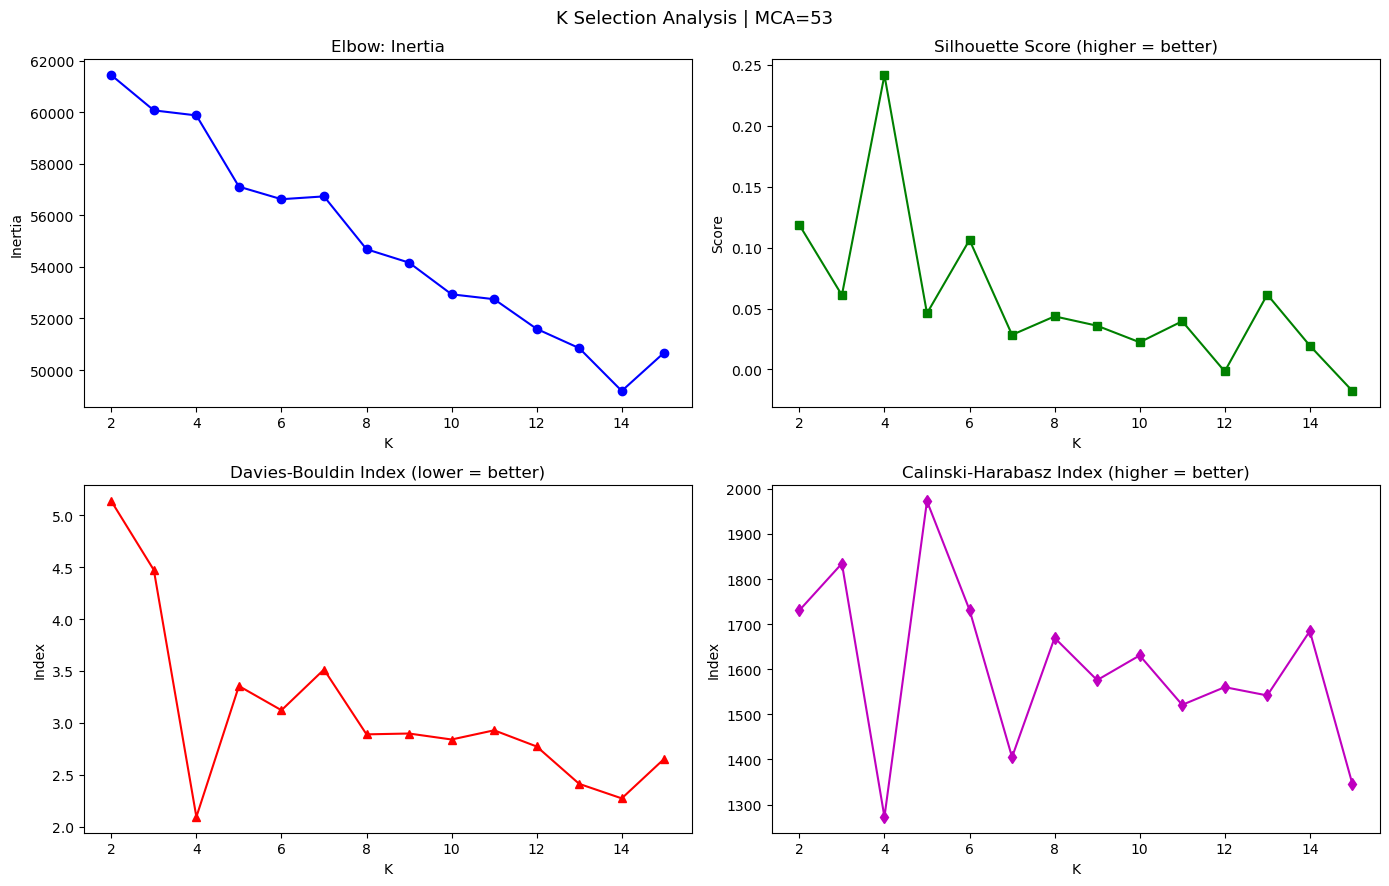

Elbow analysis done in 0:00:22
Running MCA with 61 dimensions for elbow analysis...
  K= 2  inertia=69401.9  silhouette=0.2055
  K= 3  inertia=68584.1  silhouette=0.0068
  K= 4  inertia=67256.3  silhouette=0.2309
  K= 5  inertia=66146.4  silhouette=0.0518
  K= 6  inertia=65061.3  silhouette=0.1007
  K= 7  inertia=63367.5  silhouette=0.0444
  K= 8  inertia=62300.0  silhouette=0.0317
  K= 9  inertia=61738.8  silhouette=0.0246
  K=10  inertia=60774.2  silhouette=0.0564
  K=11  inertia=59847.5  silhouette=0.0763
  K=12  inertia=59720.2  silhouette=0.0041
  K=13  inertia=58978.4  silhouette=0.0170
  K=14  inertia=57634.9  silhouette=-0.0077
  K=15  inertia=58049.1  silhouette=-0.0030
Saved: elbow_gap_results/elbow_mca61.csv, elbow_gap_results/elbow_mca61.png


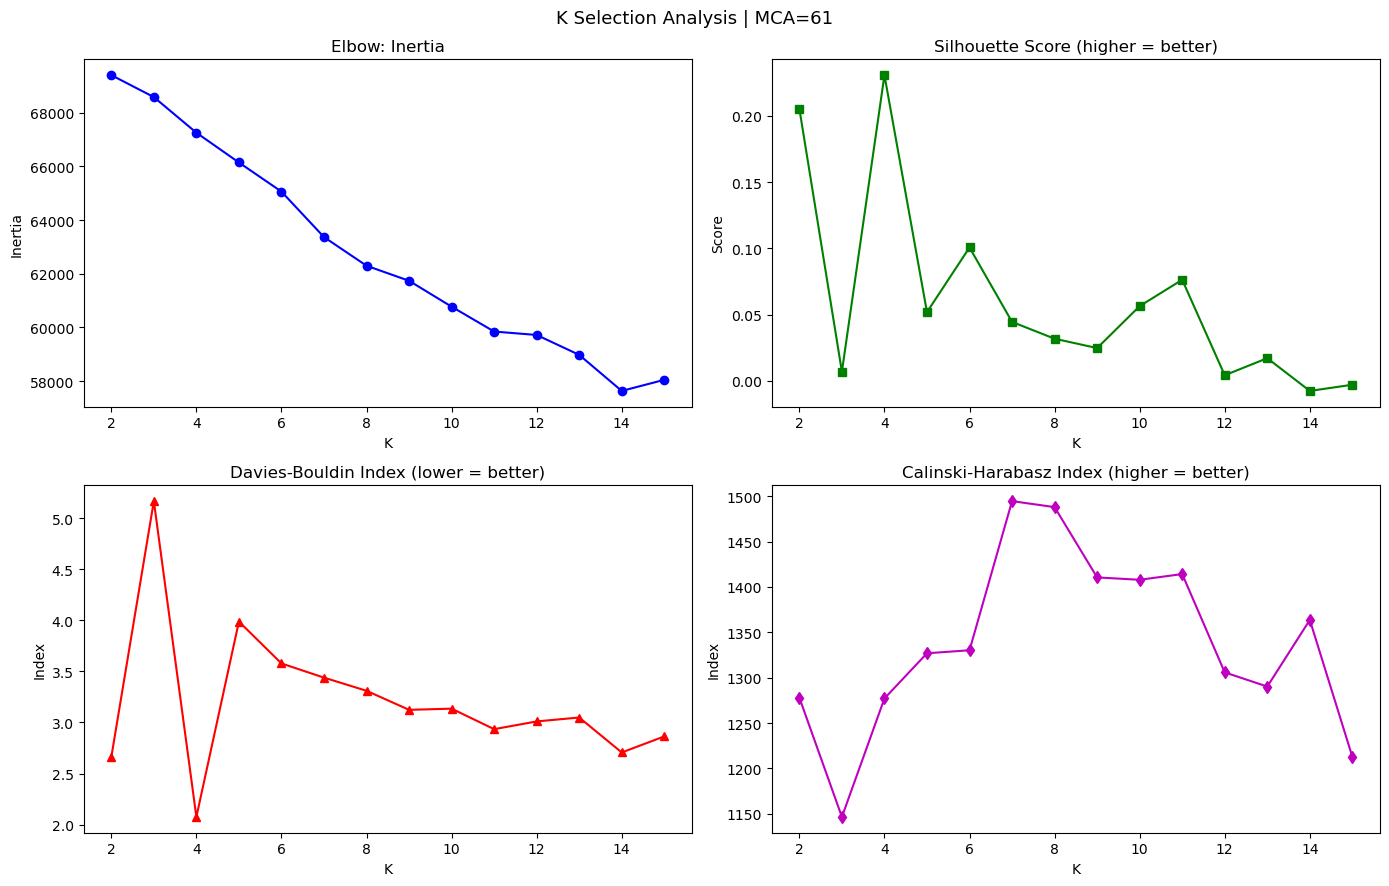

Elbow analysis done in 0:00:24
Running MCA with 73 dimensions for elbow analysis...
  K= 2  inertia=76992.6  silhouette=0.1968
  K= 3  inertia=74839.2  silhouette=0.2046
  K= 4  inertia=75274.3  silhouette=0.0817
  K= 5  inertia=74327.6  silhouette=-0.0353
  K= 6  inertia=72871.2  silhouette=0.1226
  K= 7  inertia=73186.2  silhouette=0.0817
  K= 8  inertia=69806.5  silhouette=0.0201
  K= 9  inertia=69826.9  silhouette=0.0331
  K=10  inertia=68149.0  silhouette=0.0266
  K=11  inertia=67687.0  silhouette=0.0480
  K=12  inertia=67685.5  silhouette=-0.0000
  K=13  inertia=66742.7  silhouette=0.0000
  K=14  inertia=65384.2  silhouette=0.0071
  K=15  inertia=64794.6  silhouette=0.0318
Saved: elbow_gap_results/elbow_mca73.csv, elbow_gap_results/elbow_mca73.png


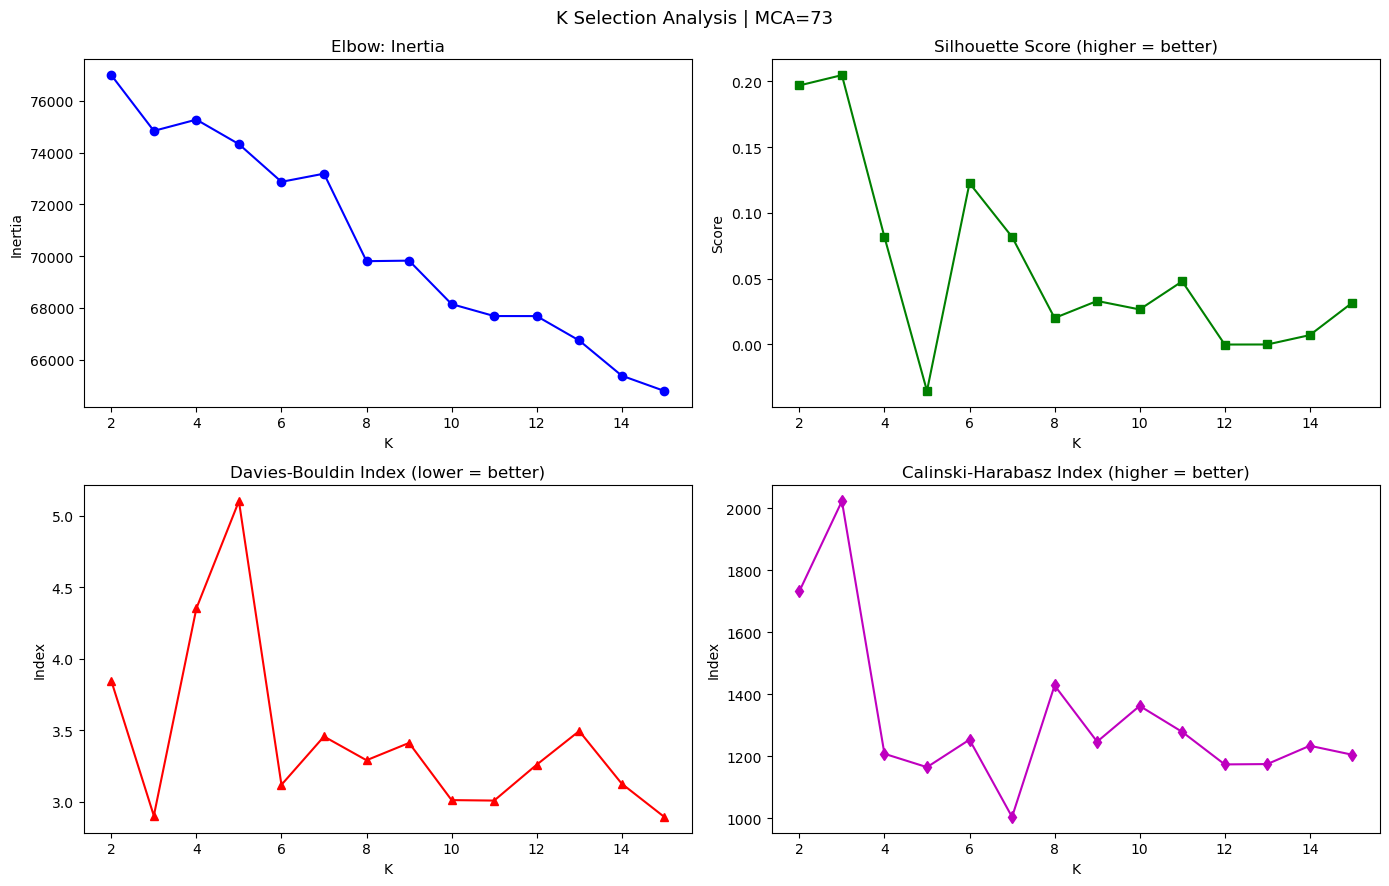

Elbow analysis done in 0:00:25


In [45]:
#step1 elbow
for mca_dim in [53, 61, 73]:
    elbow_df, X_mca_for_gap = run_elbow_analysis(
        period_sample = period_samples["2012_03_to_2017_03"],
        mca_k=mca_dim,
        cluster_numbers=range(2, 16),
        seed=42,
        output_dir="elbow_gap_results",
        show_plot=True,
    )

  K= 2  gap=3.9945  sdk=0.0129
  K= 3  gap=3.9888  sdk=0.0017
  K= 4  gap=3.9633  sdk=0.0022
  K= 5  gap=3.9597  sdk=0.0016
  K= 6  gap=3.9684  sdk=0.0030
  K= 7  gap=3.9551  sdk=0.0034
  K= 8  gap=3.9960  sdk=0.0030
  K= 9  gap=3.9904  sdk=0.0021
  K=10  gap=4.0090  sdk=0.0021
  K=11  gap=4.0125  sdk=0.0019
  K=12  gap=4.0094  sdk=0.0016
  K=13  gap=4.0197  sdk=0.0010
  K=14  gap=4.0366  sdk=0.0013
  K=15  gap=4.0428  sdk=0.0014

>>> Gap Statistic 推荐 K = 2
Saved: elbow_gap_results/gap_mca61.csv, elbow_gap_results/gap_mca61.png


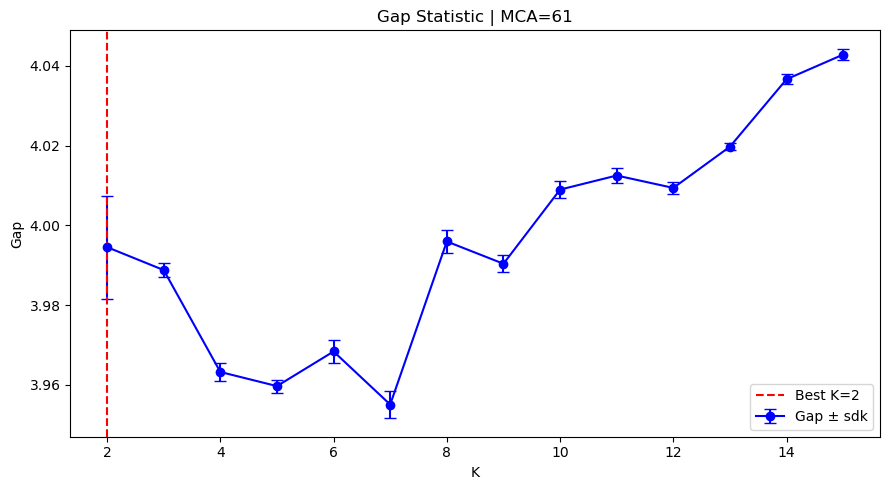

Gap statistic done in 0:01:39
Gap Statistic 推荐 K = 2


In [46]:
#step2 GAP statistic
gap_df, best_k = run_gap_statistic(
    X_mca=X_mca_for_gap,
    cluster_numbers=range(2, 16),
    n_references=10,
    seed=42,
    mca_k=61,
    output_dir="elbow_gap_results",
    show_plot=True,
)
print(f"Gap Statistic 推荐 K = {best_k}")

In [47]:
#Hyperparameter tuning
early_summary_df, early_detailed_results = run_tuning_on_period_sample(
    period_samples=period_samples,
    period_name="2012_03_to_2017_03",
    mca_dimensions=[53, 61, 73],
    mca_variance_labels={53: "80%", 61: "90%", 73: "100%"},
    cluster_numbers=[3, 4, 6, 8],
    distance_metrics=("euclidean", "jaccard"),
    run_kmeans=True,
    run_fcm=True,
    kmeans_batch_sizes=[4096, 8192, 16384],
    kmeans_n_inits=[5, 10, 20],
    fcm_m_values=[1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 4.0],
    fcm_error=0.01,
    fcm_maxiter=300,
    jaccard_kmeans_max_iter=100,
    jaccard_fcm_maxiter=100,
    silhouette_sample_size=10000,
    save_summary=True,
    save_intermediate=True,
    output_dir="2012_03_to_2017_03_hyperparameter_tuning_results",
    keep_detailed_results=False,
)
early_summary_df


Starting hyperparameter tuning
MCA dimensions: [53, 61, 73]
Cluster numbers: [3, 4, 6, 8]
Distance metrics: ('euclidean', 'jaccard')
Starting MCA dimension reduction with 53 dimensions
MCA output shape: (78669, 53)
Saved MCA data to: 2012_03_to_2017_03_hyperparameter_tuning_results/X_mca_53d.npy
Running time: 2.91 seconds (0:00:02)
Starting KMeans clustering with K = 3
   cluster  n_patients  percentage
0        0       52697   66.985725
1        1       24392   31.005860
2        2        1580    2.008415
Silhouette Score: 0.1053
Davies-Bouldin Index: 3.8575
Calinski-Harabasz Index: 1697.2655
Silhouette sample size: 10000
Running time: 1.16 seconds (0:00:01)
Starting KMeans clustering with K = 3
   cluster  n_patients  percentage
0        0       51819   65.869656
1        1       25337   32.207096
2        2        1513    1.923248
Silhouette Score: 0.0984
Davies-Bouldin Index: 3.8334
Calinski-Harabasz Index: 1666.5386
Silhouette sample size: 10000
Running time: 1.16 seconds (0:00:01

,period,mca_dimension,mca_variance_explained,algorithm,distance_metric,feature_space,cluster_k,batch_size,n_init,m,...,fpc,mean_max_membership,boundary_ratio,mean_jaccard_distance,running_time_seconds,metric_warning,label_file,membership_file,center_file,cluster_size_file
0,2012_03_to_2017_03,53,80%,KMeans,euclidean,mca_coordinates,3,4096.0,5.0,NaN,...,NaN,NaN,NaN,NaN,1.159310,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
1,2012_03_to_2017_03,53,80%,KMeans,euclidean,mca_coordinates,3,4096.0,10.0,NaN,...,NaN,NaN,NaN,NaN,1.160269,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
2,2012_03_to_2017_03,53,80%,KMeans,euclidean,mca_coordinates,3,4096.0,20.0,NaN,...,NaN,NaN,NaN,NaN,1.431357,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
3,2012_03_to_2017_03,53,80%,KMeans,euclidean,mca_coordinates,3,8192.0,5.0,NaN,...,NaN,NaN,NaN,NaN,1.247099,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
4,2012_03_to_2017_03,53,80%,KMeans,euclidean,mca_coordinates,3,8192.0,10.0,NaN,...,NaN,NaN,NaN,NaN,1.250326,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,2012_03_to_2017_03,not_used,not_used,JaccardPrototypeFCM,jaccard,raw_binary_disease_matrix,8,NaN,NaN,1.7,...,0.164707,0.205034,0.956438,NaN,3.986983,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...
316,2012_03_to_2017_03,not_used,not_used,JaccardPrototypeFCM,jaccard,raw_binary_disease_matrix,8,NaN,NaN,1.8,...,0.144115,0.163402,0.989793,NaN,4.043792,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...
317,2012_03_to_2017_03,not_used,not_used,JaccardPrototypeFCM,jaccard,raw_binary_disease_matrix,8,NaN,NaN,1.9,...,0.141601,0.159979,0.989793,NaN,4.201695,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...
318,2012_03_to_2017_03,not_used,not_used,JaccardPrototypeFCM,jaccard,raw_binary_disease_matrix,8,NaN,NaN,2.0,...,0.144714,0.168667,0.989793,NaN,4.062974,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...,2012_03_to_2017_03_hyperparameter_tuning_resul...


In [48]:
early_valid_summary_df = early_summary_df.dropna(
    subset=["silhouette_score"]
)
early_valid_summary_df.sort_values(
    by="silhouette_score",
    ascending=False
).head(10)


,period,mca_dimension,mca_variance_explained,algorithm,distance_metric,feature_space,cluster_k,batch_size,n_init,m,...,fpc,mean_max_membership,boundary_ratio,mean_jaccard_distance,running_time_seconds,metric_warning,label_file,membership_file,center_file,cluster_size_file
87,2012_03_to_2017_03,61,90%,KMeans,euclidean,mca_coordinates,3,16384.0,10.0,NaN,...,NaN,NaN,NaN,NaN,1.627830,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
88,2012_03_to_2017_03,61,90%,KMeans,euclidean,mca_coordinates,3,16384.0,20.0,NaN,...,NaN,NaN,NaN,NaN,1.801310,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
103,2012_03_to_2017_03,61,90%,KMeans,euclidean,mca_coordinates,4,8192.0,5.0,NaN,...,NaN,NaN,NaN,NaN,1.412796,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
22,2012_03_to_2017_03,53,80%,KMeans,euclidean,mca_coordinates,4,4096.0,20.0,NaN,...,NaN,NaN,NaN,NaN,1.441094,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
24,2012_03_to_2017_03,53,80%,KMeans,euclidean,mca_coordinates,4,8192.0,10.0,NaN,...,NaN,NaN,NaN,NaN,1.484239,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
81,2012_03_to_2017_03,61,90%,KMeans,euclidean,mca_coordinates,3,4096.0,10.0,NaN,...,NaN,NaN,NaN,NaN,1.518361,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
104,2012_03_to_2017_03,61,90%,KMeans,euclidean,mca_coordinates,4,8192.0,10.0,NaN,...,NaN,NaN,NaN,NaN,1.505531,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
80,2012_03_to_2017_03,61,90%,KMeans,euclidean,mca_coordinates,3,4096.0,5.0,NaN,...,NaN,NaN,NaN,NaN,1.243138,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
165,2012_03_to_2017_03,73,100%,KMeans,euclidean,mca_coordinates,3,8192.0,20.0,NaN,...,NaN,NaN,NaN,NaN,1.618525,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...
164,2012_03_to_2017_03,73,100%,KMeans,euclidean,mca_coordinates,3,8192.0,10.0,NaN,...,NaN,NaN,NaN,NaN,1.455761,None,2012_03_to_2017_03_hyperparameter_tuning_resul...,None,None,2012_03_to_2017_03_hyperparameter_tuning_resul...


In [49]:
from sklearn.preprocessing import MinMaxScaler

rank_df = early_valid_summary_df.copy()

# Keep only valid rows (all three metrics are non-NaN)
rank_df = rank_df.dropna(subset=["silhouette_score", "davies_bouldin_index", "calinski_harabasz_index"])

# Normalize to the [0, 1] range
scaler = MinMaxScaler()
rank_df["sil_norm"]  = scaler.fit_transform(rank_df[["silhouette_score"]])
rank_df["dbi_norm"]  = 1 - scaler.fit_transform(rank_df[["davies_bouldin_index"]])   # 反转：越低越好
rank_df["ch_norm"]   = scaler.fit_transform(rank_df[["calinski_harabasz_index"]])

# Composite score (equal weighting across the three metrics)
rank_df["composite_score"] = (rank_df["sil_norm"] + rank_df["dbi_norm"] + rank_df["ch_norm"]) / 3

ranking_df = rank_df.sort_values("composite_score", ascending=False)
ranking_df.index.name = "row_index"  
ranking_df.to_csv(
    "2012_03_to_2017_03_full_ranking.csv",
    index=True     
)

ranking_df[[
    "period", "algorithm", "distance_metric", "mca_dimension",
    "cluster_k", "silhouette_score", "davies_bouldin_index",
    "calinski_harabasz_index", "composite_score"
]].head(50)

,period,algorithm,distance_metric,mca_dimension,cluster_k,silhouette_score,davies_bouldin_index,calinski_harabasz_index,composite_score
row_index,,,,,,,,,
88,2012_03_to_2017_03,KMeans,euclidean,61,3,0.370046,1.410718,1893.697839,0.897491
87,2012_03_to_2017_03,KMeans,euclidean,61,3,0.370046,1.410718,1893.697839,0.897491
103,2012_03_to_2017_03,KMeans,euclidean,61,4,0.334544,1.382576,1711.546917,0.849330
7,2012_03_to_2017_03,KMeans,euclidean,53,3,0.203470,3.063545,2608.181397,0.819586
8,2012_03_to_2017_03,KMeans,euclidean,53,3,0.201741,3.052939,2606.012438,0.818577
165,2012_03_to_2017_03,KMeans,euclidean,73,3,0.207566,2.779014,1998.869644,0.747753
164,2012_03_to_2017_03,KMeans,euclidean,73,3,0.204616,2.901455,2023.495286,0.744184
163,2012_03_to_2017_03,KMeans,euclidean,73,3,0.203663,2.872550,2018.752620,0.744086
25,2012_03_to_2017_03,KMeans,euclidean,53,4,0.148900,3.391170,2297.124645,0.725674


In [50]:
# Check for errors
early_summary_df[
    early_summary_df["metric_warning"].notna()
][[
    "period", "algorithm", "distance_metric", "cluster_k", "m", "metric_warning"
]].head(20)


,period,algorithm,distance_metric,cluster_k,m,metric_warning


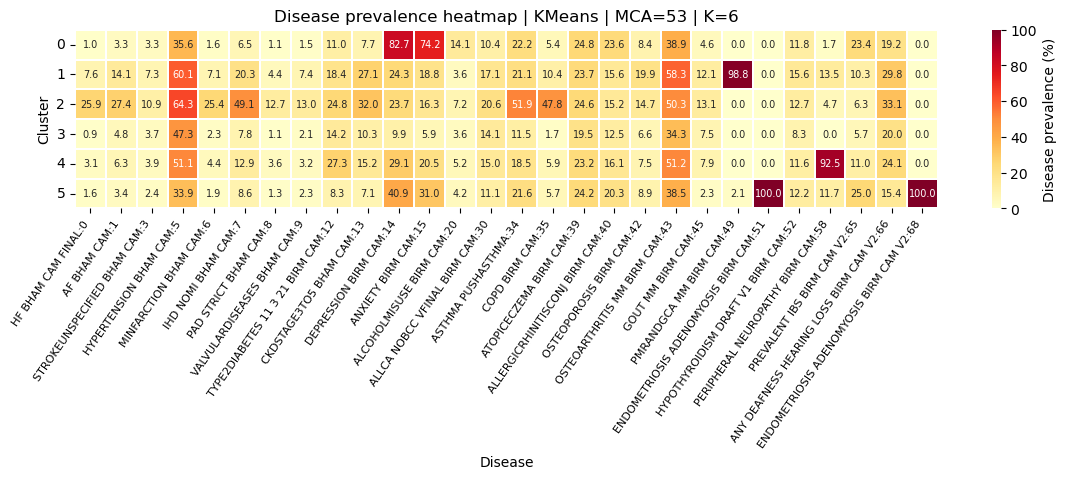

{'prevalence_all_csv': '2012_03_to_2017_03_hyperparameter_tuning_results/mca53_kmeans_K6_disease_heatmap_prevalence_all.csv',
 'prevalence_shown_csv': '2012_03_to_2017_03_hyperparameter_tuning_results/mca53_kmeans_K6_disease_heatmap_prevalence_shown.csv',
 'cluster_size_csv': '2012_03_to_2017_03_hyperparameter_tuning_results/mca53_kmeans_K6_disease_heatmap_cluster_size.csv',
 'heatmap_png': '2012_03_to_2017_03_hyperparameter_tuning_results/mca53_kmeans_K6_disease_heatmap.png'}

In [51]:
# 2012_03_to_2017_03
best_row_index = 45  # Change to the desired line number
prevalence_df, shown_df, heatmap_files = plot_selected_result_heatmap(
    summary_df=early_summary_df,
    row_index=best_row_index,
    period_samples=period_samples,
    top_n=None,
    min_cluster_prevalence=10,
    short_disease_names=True,
    annot=True,
    number_format=".1f",
    save_outputs=True,
    show_plot=True,
)
heatmap_files

In [52]:
"""
Cluster Disease Characterisation
 
Definitions of the three metrics:

- Frequency:
  Disease prevalence (%) within the cluster.

- O/E ratio:
  Disease prevalence in the cluster divided by its prevalence
  in the entire active cohort.

- Exclusivity:
  Number of patients with the disease in the cluster divided by
  the total number of patients with the disease in the active cohort (%).

Outputs:
- One CSV file per cluster containing the top 20 diseases for each metric.
- One Excel workbook with one worksheet per cluster, where each worksheet
  contains the three Top 20 tables displayed side by side.
"""
def characterise_clusters(
    labels,
    disease_data,
    top_n=20,
    min_global_prevalence=0.005,
    output_dir="cluster_characterisation",
    file_prefix="2012_03_to_2017_03",
    short_disease_names=True,
    disease_prefix="B_MEDI:",
    save_outputs=True,
):
    output_dir = Path(output_dir)
    if save_outputs:
        output_dir.mkdir(parents=True, exist_ok=True)

    labels = np.asarray(labels)
    X = disease_data.X_numeric.copy().reset_index(drop=True)

    if len(labels) != len(X):
        raise ValueError(
            f"labels 长度 ({len(labels)}) 与 disease_data 行数 ({len(X)}) 不一致。"
        )

    def _shorten(col):
        return (
            str(col)
            .replace(disease_prefix, "")
            .replace("B_MEDI:", "")
            .replace("B.M.", "")
            .replace("B_", "")
            .replace("_", " ")
            .strip()
        )

    disease_cols = list(X.columns)
    display_names = {col: _shorten(col) if short_disease_names else col
                     for col in disease_cols}

    n_total = len(X)
    global_count = X.sum(axis=0)
    global_prev  = global_count / n_total

    valid_diseases = global_prev[global_prev >= min_global_prevalence].index.tolist()
    X_valid = X[valid_diseases]
    global_count_v = global_count[valid_diseases]
    global_prev_v  = global_prev[valid_diseases]

    cluster_ids = sorted(np.unique(labels))
    cluster_stats = {}
    all_records = []

    for cid in cluster_ids:
        mask = labels == cid
        X_c = X_valid.loc[mask]
        n_c = mask.sum()

        cluster_prev = X_c.mean(axis=0)
        freq_pct     = cluster_prev * 100
        oe           = cluster_prev / global_prev_v.replace(0, np.nan)
        cluster_count = X_c.sum(axis=0)
        exclusivity  = (cluster_count / global_count_v.replace(0, np.nan)) * 100

        def _top(series, metric_name):
            ranked = (
                series
                .dropna()
                .sort_values(ascending=False)
                .head(top_n)
                .reset_index()
            )
            ranked.columns = ["disease_col", metric_name]
            ranked["disease_name"]    = ranked["disease_col"].map(display_names)
            ranked["cluster"]         = cid
            ranked["n_cluster"]       = n_c
            ranked["rank"]            = range(1, len(ranked) + 1)
            ranked["global_prev_pct"] = (
                global_prev_v[ranked["disease_col"]].values * 100
            )
            return ranked[["rank", "disease_name", metric_name,
                            "global_prev_pct", "cluster", "n_cluster", "disease_col"]]

        freq_df = _top(freq_pct,    "frequency_pct")
        oe_df   = _top(oe,          "OE_ratio")
        excl_df = _top(exclusivity, "exclusivity_pct")

        cluster_stats[cid] = {
            "frequency":   freq_df,
            "oe":          oe_df,
            "exclusivity": excl_df,
        }

        for df, metric in [(freq_df, "frequency"), (oe_df, "oe"), (excl_df, "exclusivity")]:
            tmp = df.copy()
            tmp["metric"] = metric
            all_records.append(tmp)

    combined_df = pd.concat(all_records, ignore_index=True)

    if save_outputs:
        excel_path = output_dir / f"{file_prefix}_cluster_top{top_n}_characterisation.xlsx"
        with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
            for cid, metrics in cluster_stats.items():
                sheet_name = f"Cluster_{cid}"
                freq_df = metrics["frequency"]
                oe_df   = metrics["oe"]
                excl_df = metrics["exclusivity"]
                n_cluster = int(freq_df["n_cluster"].iloc[0])

                freq_df.to_excel(writer, sheet_name=sheet_name,
                                 startrow=1, startcol=0, index=False)
                oe_df.to_excel(writer, sheet_name=sheet_name,
                               startrow=1, startcol=len(freq_df.columns) + 2, index=False)
                excl_df.to_excel(writer, sheet_name=sheet_name,
                                 startrow=1, startcol=(len(freq_df.columns) + 2) * 2, index=False)

                ws = writer.sheets[sheet_name]
                ws.cell(1, 1, f"Cluster {cid} (n={n_cluster}) ── Frequency Top {top_n}")
                ws.cell(1, len(freq_df.columns) + 3,
                        f"Cluster {cid} (n={n_cluster}) ── O/E Ratio Top {top_n}")
                ws.cell(1, (len(freq_df.columns) + 2) * 2 + 1,
                        f"Cluster {cid} (n={n_cluster}) ── Exclusivity Top {top_n}")

                csv_path = output_dir / f"{file_prefix}_cluster{cid}_top{top_n}.csv"
                pd.concat([
                    freq_df.assign(metric="frequency"),
                    oe_df.assign(metric="oe"),
                    excl_df.assign(metric="exclusivity"),
                ], ignore_index=True).to_csv(csv_path, index=False)
                print(f"  Saved Cluster {cid} → {csv_path}")

        print(f"\nExcel → {excel_path}")
        combined_df.to_csv(output_dir / f"{file_prefix}_all_clusters_top{top_n}.csv", index=False)

    return cluster_stats, combined_df

In [53]:
# MCA=53, K=6, batch_size=8192, n_init=20 
disease_data = period_samples["2012_03_to_2017_03"].active_disease_data
# Step 1: MCA 
X_mca, _ = run_mca_dimension_reduction(
    mca_k=53,
    disease_data=disease_data,
    seed=42,
    save_output=False,
)
# Step 2: KMeans
import os
os.makedirs("2012_03_to_2017_03_hyperparameter_tuning_results", exist_ok=True)
result = run_kmeans_evaluation(
    X_mca_values=X_mca,
    cluster_k=6,
    seed=42,
    batch_size=8192,
    n_init=20,
    silhouette_sample_size=10000,
    save_labels=True,
    save_cluster_size=True,
    output_dir="2012_03_to_2017_03_hyperparameter_tuning_results",
    file_prefix="mca53_euclidean_kmeans_bs4096_ninit10",
)
labels = result["labels"]
print("完成！cluster 分布：")
print(result["cluster_size"])
# Step 3: 
cluster_stats, combined_df = characterise_clusters(
    labels=labels,
    disease_data=disease_data,
    top_n=20,
    min_global_prevalence=0.005,
    output_dir="cluster_characterisation",
    file_prefix="2012_03_to_2017_03_mca53_K6",
    short_disease_names=True,
    disease_prefix="B_MEDI:",
    save_outputs=True,
)
# Step 4: results
for cid in sorted(cluster_stats.keys()):
    print(f"\n{'='*60}")
    print(f"Cluster {cid}  (n={result['cluster_size'].loc[cid, 'n_patients']})")
    print(f"{'='*60}")
    print("── Frequency Top 20 ──")
    print(cluster_stats[cid]["frequency"].to_string(index=False))
    print("\n── O/E Top 20 ──")
    print(cluster_stats[cid]["oe"].to_string(index=False))
    print("\n── Exclusivity Top 20 ──")
    print(cluster_stats[cid]["exclusivity"].to_string(index=False))

Starting MCA dimension reduction with 53 dimensions
MCA output shape: (78669, 53)
Running time: 2.88 seconds (0:00:02)
Starting KMeans clustering with K = 6
   cluster  n_patients  percentage
0        0       14079   17.896503
1        1        2166    2.753308
2        2       10254   13.034359
3        3       44583   56.671624
4        4        6723    8.545933
5        5         864    1.098273
Silhouette Score: 0.1104
Davies-Bouldin Index: 3.1521
Calinski-Harabasz Index: 1805.2888
Silhouette sample size: 10000
Running time: 1.71 seconds (0:00:01)
完成！cluster 分布：
   cluster  n_patients  percentage
0        0       14079   17.896503
1        1        2166    2.753308
2        2       10254   13.034359
3        3       44583   56.671624
4        4        6723    8.545933
5        5         864    1.098273
  Saved Cluster 0 → cluster_characterisation/2012_03_to_2017_03_mca53_K6_cluster0_top20.csv
  Saved Cluster 1 → cluster_characterisation/2012_03_to_2017_03_mca53_K6_cluster1_top20.cs